In [ ]:
# ==========================================
# CELL #1 - ENVIRONMENT SETUP & GPU CHECK
# ==========================================
import os
import random
import numpy as np
import tensorflow as tf

print("🔧 Initializing Workspace...\n")

# 1. LOCK THE RANDOM SEEDS (For the Unified Baseline Experiment)
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f"🔒 Random Seeds Locked at {SEED}. Data augmentation will be 100% reproducible.")

# 2. CHECK HARDWARE AND CONFIGURE MEMORY
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        # Prevent TensorFlow from claiming all 4GB at once!
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        
        logical_gpus = tf.config.list_logical_devices('GPU')
        print(f"\n✅ GPU DETECTED: {len(gpus)} Physical GPU(s), {len(logical_gpus)} Logical GPU(s).")
        print(f"✅ Memory Growth Enabled. Your 4GB GPU is protected from greedy allocation.")
        
        # Print the exact name of your GPU
        gpu_details = tf.config.experimental.get_device_details(gpus[0])
        print(f"🎮 GPU Name: {gpu_details.get('device_name', 'Unknown GTX Card')}")

    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(f"❌ Error configuring GPU: {e}")
else:
    print("\n❌ NO GPU DETECTED. TensorFlow is running on the CPU. Check your CUDA/cuDNN installation!")

print("\n🚀 Environment is stable and ready for Phase 1.")

🔧 Initializing Workspace...

🔒 Random Seeds Locked at 42. Data augmentation will be 100% reproducible.

✅ GPU DETECTED: 1 Physical GPU(s), 1 Logical GPU(s).
✅ Memory Growth Enabled. Your 4GB GPU is protected from greedy allocation.
🎮 GPU Name: NVIDIA GeForce GTX 1650

🚀 Environment is stable and ready for Phase 1.


🔍 Scanning Dataset Directories...

✅ Found 15 Classes:

  🌾 potato_bacteria: 398 Train | 85 Val
  🌾 potato_early_blight: 351 Train | 75 Val
  🌾 potato_fungi: 489 Train | 105 Val
  🌾 potato_healthy: 452 Train | 97 Val
  🌾 potato_late_blight: 202 Train | 43 Val
  🌾 rice_blast: 579 Train | 124 Val
  🌾 rice_brown_spot: 296 Train | 63 Val
  🌾 rice_healthy: 175 Train | 37 Val
  🌾 rice_sheath_blight: 350 Train | 75 Val
  🌾 rice_tungro_virus: 167 Train | 35 Val
  🌾 wheat_black_point: 212 Train | 45 Val
  🌾 wheat_blast: 280 Train | 60 Val
  🌾 wheat_fusarium_foot_rot: 175 Train | 37 Val
  🌾 wheat_healthy: 175 Train | 37 Val
  🌾 wheat_leaf_blight: 280 Train | 60 Val

📊 TOTAL IMAGES: 4581 Training | 978 Validation


C:\Users\shiha\AppData\Local\Temp\ipykernel_252\2238996419.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Image Count', y='Class', data=df_sorted, palette='viridis')


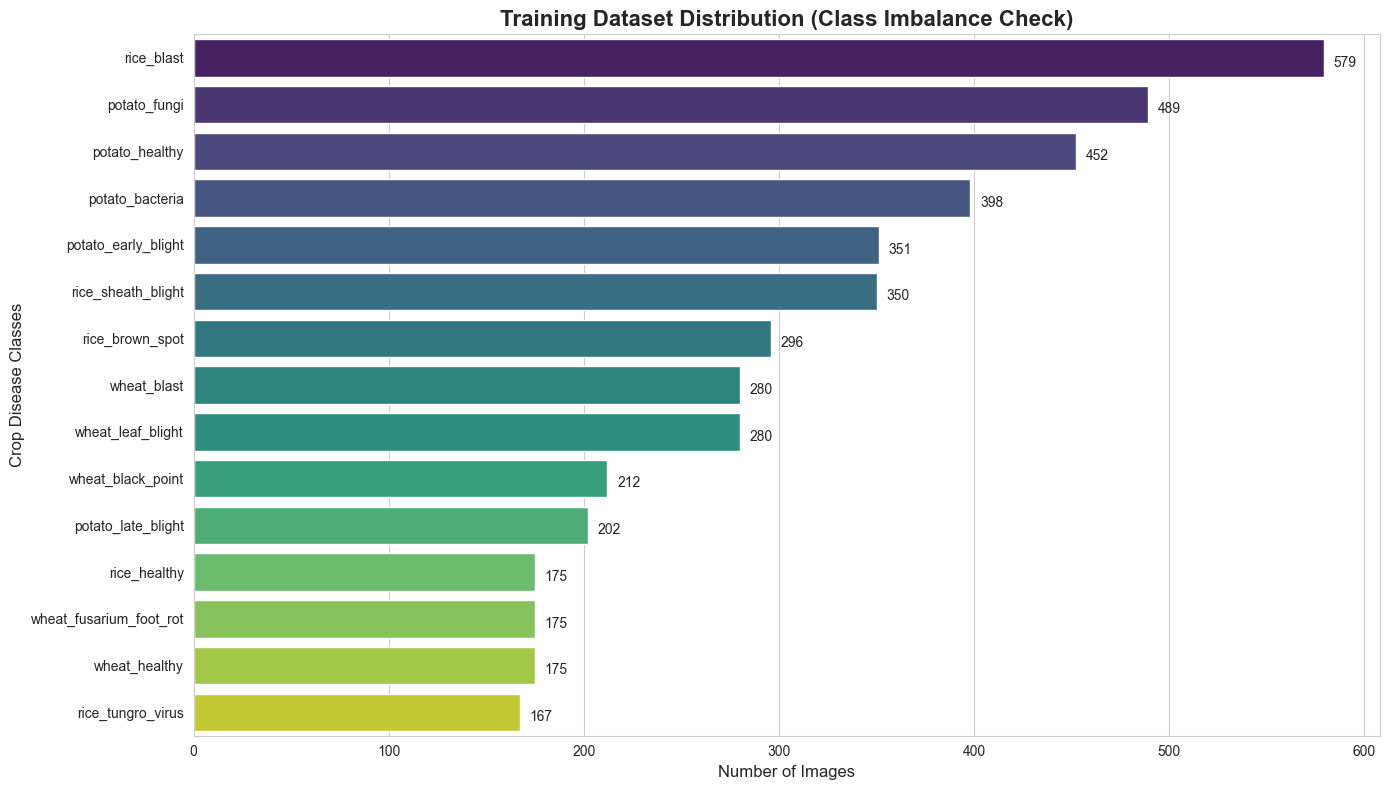


✅ Visualization Complete. Check the chart above to see which classes need the most help from class weights!


In [2]:
# ==========================================
# CELL #2 - DATASET EXPLORATION & VISUALIZATION
# ==========================================
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("🔍 Scanning Dataset Directories...\n")

# Define your paths
DATASET_DIR = r"D:\MasterDataset"
TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR = os.path.join(DATASET_DIR, "val")

# Get classes
classes = sorted(os.listdir(TRAIN_DIR))
print(f"✅ Found {len(classes)} Classes:\n")

# Count images
train_counts = []
val_counts = []

for cls in classes:
    train_cls_path = os.path.join(TRAIN_DIR, cls)
    val_cls_path = os.path.join(VAL_DIR, cls)
    
    # Count files in each directory
    t_count = len(os.listdir(train_cls_path)) if os.path.exists(train_cls_path) else 0
    v_count = len(os.listdir(val_cls_path)) if os.path.exists(val_cls_path) else 0
    
    train_counts.append(t_count)
    val_counts.append(v_count)
    
    print(f"  🌾 {cls}: {t_count} Train | {v_count} Val")

total_train = sum(train_counts)
total_val = sum(val_counts)
print(f"\n📊 TOTAL IMAGES: {total_train} Training | {total_val} Validation")

# ------------------------------------------
# VISUALIZE THE TRAINING DISTRIBUTION
# ------------------------------------------
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# Create a DataFrame for easier plotting with Seaborn
df = pd.DataFrame({
    'Class': classes,
    'Image Count': train_counts
})

# Sort values to make the chart look professional
df_sorted = df.sort_values('Image Count', ascending=False)

# Plot
ax = sns.barplot(x='Image Count', y='Class', data=df_sorted, palette='viridis')
plt.title('Training Dataset Distribution (Class Imbalance Check)', fontsize=16, fontweight='bold')
plt.xlabel('Number of Images', fontsize=12)
plt.ylabel('Crop Disease Classes', fontsize=12)

# Add the exact numbers to the end of each bar
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 5, p.get_y() + p.get_height()/2. + 0.1, '{:1.0f}'.format(width), 
             ha="left", va="center", fontsize=10)

plt.tight_layout()
plt.show()

print("\n✅ Visualization Complete. Check the chart above to see which classes need the most help from class weights!")

In [1]:
# ==========================================
# CELL #3 - THE UPGRADED UNIFIED DATA PIPELINE
# ==========================================
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight

print("⚙️ Building the Upgraded Unified Data Pipeline...\n")

BATCH_SIZE = 16 
IMG_SIZE = (224, 224)

# 1. THE SINGLE MASTER GENERATOR (UNSCALED BUT HIGHLY AUGMENTED)
# 🚨 CRITICAL: No rescale=1./255! We must keep raw pixels for EfficientNet.
master_train_datagen = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    shear_range=0.1,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode='nearest'
)
master_val_datagen = ImageDataGenerator() # Clean, unscaled validation

# 2. FLOW FROM DIRECTORY (USING OUR LOCKED SEED)
print("Loading Training Data...")
train_gen = master_train_datagen.flow_from_directory(
    r"D:\MasterDataset\train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42  # <- Locked for the Master Experiment
)

print("Loading Validation Data...")
val_gen = master_val_datagen.flow_from_directory(
    r"D:\MasterDataset\val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=42
)

# 3. CALCULATE CLASS WEIGHTS
print("\n⚖️ Calculating Class Weights for Imbalanced Data...")
train_classes = train_gen.classes
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_classes),
    y=train_classes
)

# Convert to a dictionary and force float types
class_weight_dict = {int(k): float(v) for k, v in enumerate(class_weights_array)}

print("✅ Upgraded Unified Data Pipeline is Ready!")

⚙️ Building the Upgraded Unified Data Pipeline...

Loading Training Data...
Found 4581 images belonging to 15 classes.
Loading Validation Data...
Found 978 images belonging to 15 classes.

⚖️ Calculating Class Weights for Imbalanced Data...
✅ Upgraded Unified Data Pipeline is Ready!


In [2]:
# ==========================================
# CELL #4 - PHASE 1: DENSENET121 (FEATURE EXTRACTION)
# ==========================================
import os
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Input, Rescaling, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

print("🧹 Flushing GPU Memory...")
tf.keras.backend.clear_session() 

print("🏗️ Building Phase 1: DenseNet121 Feature Extractor...\n")

# 1. THE INTERNAL SCALER 
inputs = Input(shape=(224, 224, 3), name="raw_image_input")
scaled_inputs = Rescaling(1./255, name="internal_rescaler")(inputs)

# 2. THE BASE MODEL (Frozen)
base_densenet = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_densenet.trainable = False # 🔒 STRICTLY FROZEN FOR PHASE 1

# Pass scaled inputs. training=False mathematically locks Batch Normalization.
x = base_densenet(scaled_inputs, training=False) 

# 3. THE CUSTOM 15-CLASS HEAD
x = GlobalAveragePooling2D(name="global_pooling")(x)
x = Dropout(0.3, name="head_dropout")(x) 
outputs = Dense(15, activation='softmax', name="final_predictions")(x)

# Assemble
densenet_phase1 = Model(inputs=inputs, outputs=outputs, name="DenseNet_Phase1_Base")

# 4. COMPILE 
densenet_phase1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

densenet_phase1.summary()

# 5. ISOLATED DIRECTORY & CALLBACKS
# 🚨 NEW: Creating a dedicated folder for this final master run!
FINAL_DIR = r"D:\Final_Experiment"
os.makedirs(FINAL_DIR, exist_ok=True)
model_path = os.path.join(FINAL_DIR, "DenseNet121_Base.keras")

callbacks = [
    ModelCheckpoint(model_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

# 6. TRAIN ONLY THE HEAD
print("\n🚀 Starting Phase 1 Training (Feature Extraction)...")
history_dense_p1 = densenet_phase1.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25, # 🚨 NEW: Extended runway to let EarlyStopping do its job
    class_weight=class_weight_dict,
    callbacks=callbacks
)

print(f"\n✅ Phase 1 Complete! Base model safely isolated at: {model_path}")

🧹 Flushing GPU Memory...
🏗️ Building Phase 1: DenseNet121 Feature Extractor...

Model: "DenseNet_Phase1_Base"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 raw_image_input (InputLayer  [(None, 224, 224, 3)]    0         
 )                                                               
                                                                 
 internal_rescaler (Rescalin  (None, 224, 224, 3)      0         
 g)                                                              
                                                                 
 densenet121 (Functional)    (None, 7, 7, 1024)        7037504   
                                                                 
 global_pooling (GlobalAvera  (None, 1024)             0         
 gePooling2D)                                                    
                                                                 
 head_dropout (Dropout)      (No

In [3]:
# ==========================================
# CELL #5 - PHASE 2: DENSENET121 (FINE-TUNING)
# ==========================================
import os
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

print("🧹 Flushing GPU Memory for Fine-Tuning...")
tf.keras.backend.clear_session() 

print("🔓 Loading Phase 1 Model for Brain Surgery...\n")

# 1. LOAD THE PHASE 1 MODEL
FINAL_DIR = r"D:\Final_Experiment"
phase1_path = os.path.join(FINAL_DIR, "DenseNet121_Base.keras")
densenet_finetune = load_model(phase1_path)

# 2. LOCATE THE BASE MODEL AND UNFREEZE IT
# In Keras, the pre-trained base is stored as a nested layer. 
# For DenseNet121, its default internal name is 'densenet121'.
base_layer = densenet_finetune.get_layer('densenet121')
base_layer.trainable = True 

# 3. SURGICAL FREEZE (Keep early layers locked, open the last 50)
print("🔬 Performing Surgical Unfreeze (Unlocking last 50 layers)...")
for layer in base_layer.layers[:-50]:
    layer.trainable = False

# Verify how many layers are actually trainable now
trainable_count = sum([1 for w in densenet_finetune.trainable_weights])
print(f"✅ Ready! {trainable_count} weight tensors are now unlocked for training.")

# 4. RECOMPILE WITH MICROSCOPIC LEARNING RATE
# 🚨 CRITICAL: If you use 0.001 here, the model will suffer "Catastrophic Forgetting"
densenet_finetune.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # Microscopic LR (0.00001)
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 5. NEW CALLBACKS (Save as FineTuned)
finetuned_path = os.path.join(FINAL_DIR, "DenseNet121_FineTuned.keras")

callbacks_ft = [
    ModelCheckpoint(finetuned_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    # If it gets stuck, drop the LR even further!
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1) 
]

# 6. COMMENCE FINE-TUNING
print("\n🚀 Starting Phase 2 Training (Fine-Tuning)...")
history_dense_ft = densenet_finetune.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20, # 20 epochs is plenty for fine-tuning
    class_weight=class_weight_dict,
    callbacks=callbacks_ft
)

print(f"\n👑 Phase 2 Complete! DenseNet121 is fully specialized and saved at: {finetuned_path}")

🧹 Flushing GPU Memory for Fine-Tuning...
🔓 Loading Phase 1 Model for Brain Surgery...

🔬 Performing Surgical Unfreeze (Unlocking last 50 layers)...
✅ Ready! 44 weight tensors are now unlocked for training.

🚀 Starting Phase 2 Training (Fine-Tuning)...
Epoch 1/20
287/287 [==============================] - ETA: 0s - loss: 0.2959 - accuracy: 0.8769
Epoch 1: val_accuracy improved from -inf to 0.92025, saving model to D:\Final_Experiment\DenseNet121_FineTuned.keras
287/287 [==============================] - 92s 296ms/step - loss: 0.2959 - accuracy: 0.8769 - val_loss: 0.2534 - val_accuracy: 0.9202 - lr: 1.0000e-05
Epoch 2/20
287/287 [==============================] - ETA: 0s - loss: 0.2704 - accuracy: 0.8858
Epoch 2: val_accuracy did not improve from 0.92025
287/287 [==============================] - 84s 292ms/step - loss: 0.2704 - accuracy: 0.8858 - val_loss: 0.2543 - val_accuracy: 0.9141 - lr: 1.0000e-05
Epoch 3/20
287/287 [==============================] - ETA: 0s - loss: 0.2778 - accurac

🧹 Flushing GPU Memory for Evaluation...
🔍 Loading Model: D:\Final_Experiment\DenseNet121_FineTuned.keras

📊 Running standard evaluation...
62/62 [==============================] - 21s 260ms/step - loss: 0.2034 - accuracy: 0.9325

🏆 DENSENET121 FINAL ACCURACY: 93.25%

🕵️‍♂️ Generating predictions for the Confusion Matrix...
62/62 [==============================] - 21s 281ms/step

📄 --- CLASSIFICATION REPORT ---
                         precision    recall  f1-score   support

        potato_bacteria       0.96      0.95      0.96        85
    potato_early_blight       0.99      0.96      0.97        75
           potato_fungi       0.93      0.92      0.93       105
         potato_healthy       0.93      0.94      0.93        97
     potato_late_blight       0.89      0.95      0.92        43
             rice_blast       0.87      0.91      0.89       124
        rice_brown_spot       0.89      0.81      0.85        63
           rice_healthy       0.89      0.84      0.86        37


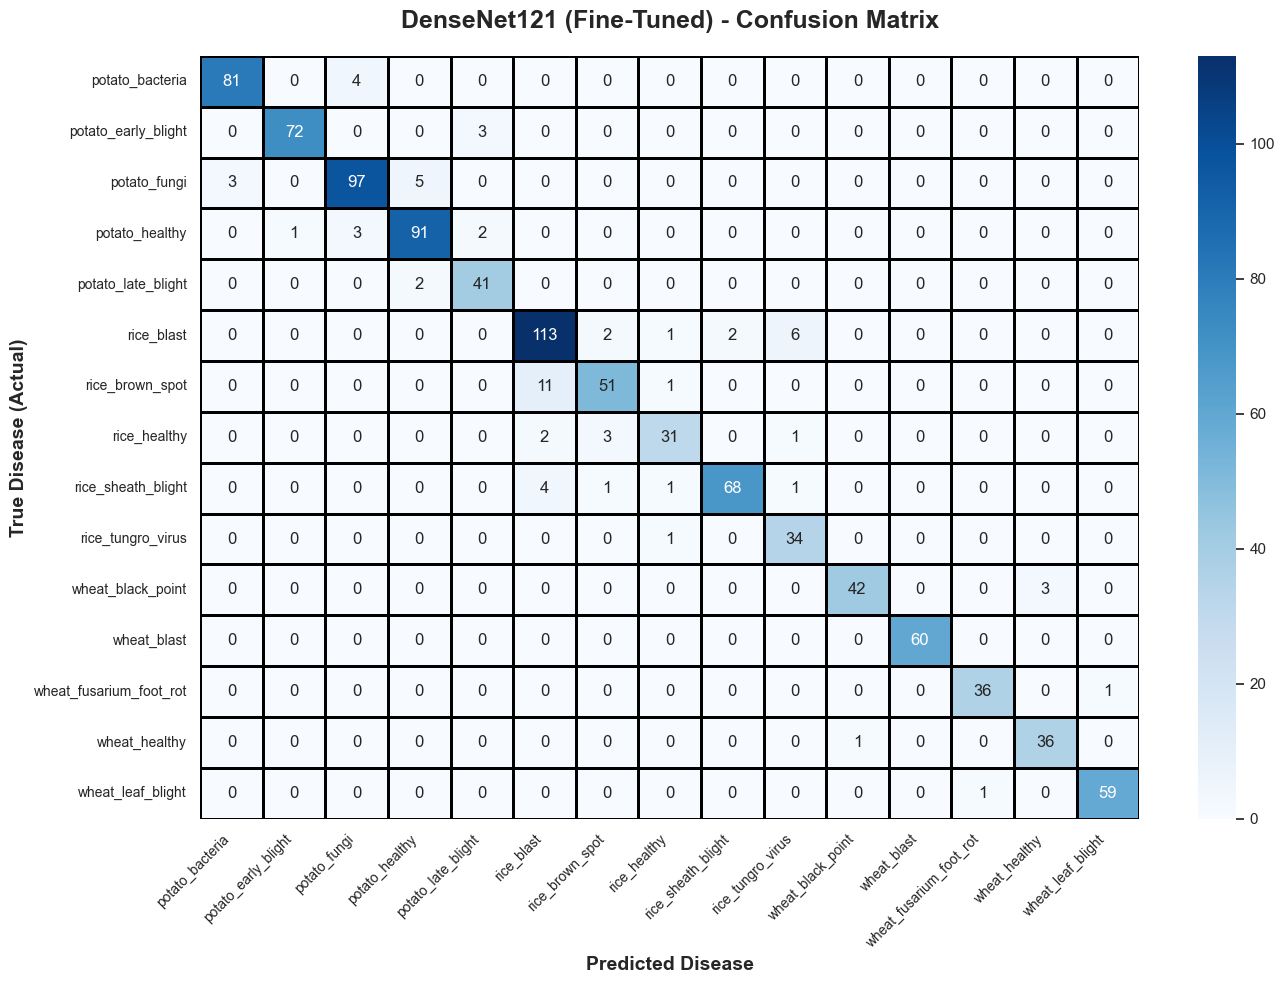

✅ Evaluation Complete! Save this chart for your thesis.


In [4]:
# ==========================================
# CELL #6 - EVALUATION & CONFUSION MATRIX
# ==========================================
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix

print("🧹 Flushing GPU Memory for Evaluation...")
tf.keras.backend.clear_session()

# 1. LOAD THE FINE-TUNED MODEL
FINAL_DIR = r"D:\Final_Experiment"
model_path = os.path.join(FINAL_DIR, "DenseNet121_FineTuned.keras")

print(f"🔍 Loading Model: {model_path}")
eval_model = load_model(model_path)

# 2. CALCULATE 2-DECIMAL ACCURACY
print("\n📊 Running standard evaluation...")
loss, accuracy = eval_model.evaluate(val_gen, verbose=1)
print(f"\n🏆 DENSENET121 FINAL ACCURACY: {accuracy * 100:.2f}%")

# 3. GENERATE PREDICTIONS FOR THE CONFUSION MATRIX
print("\n🕵️‍♂️ Generating predictions for the Confusion Matrix...")
# Reset generator to ensure it starts from the very first image
val_gen.reset() 
predictions = eval_model.predict(val_gen, verbose=1)

# Convert probabilities to actual class indices (0 to 14)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = val_gen.classes
class_labels = list(val_gen.class_indices.keys())

# 4. PRINT CLASSIFICATION REPORT (Precision, Recall, F1-Score)
print("\n📄 --- CLASSIFICATION REPORT ---")
report = classification_report(true_classes, predicted_classes, target_names=class_labels)
print(report)

# 5. PLOT THE CONFUSION MATRIX
print("\n🎨 Plotting Confusion Matrix...")
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(14, 10))
sns.set_theme(style="whitegrid") # Clean background

# Create the heatmap
heatmap = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                      xticklabels=class_labels, 
                      yticklabels=class_labels,
                      linewidths=1, linecolor='black')

# Formatting for thesis-level professionalism
plt.title('DenseNet121 (Fine-Tuned) - Confusion Matrix', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Predicted Disease', fontsize=14, fontweight='bold')
plt.ylabel('True Disease (Actual)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

print("✅ Evaluation Complete! Save this chart for your thesis.")

In [5]:
# ==========================================
# CELL #7 - PHASE 1: MOBILENETV2 (FEATURE EXTRACTION)
# ==========================================
import os
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, Rescaling, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

print("🧹 Flushing GPU Memory...")
tf.keras.backend.clear_session() 

print("🏗️ Building Phase 1: MobileNetV2 Feature Extractor...\n")

# 1. THE INTERNAL SCALER 
# Matching the exact 1./255 scaling logic from your Fusion Boss model
inputs = Input(shape=(224, 224, 3), name="raw_image_input")
scaled_inputs = Rescaling(1./255, name="internal_rescaler")(inputs)

# 2. THE BASE MODEL (Frozen)
base_mobilenet = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_mobilenet.trainable = False # 🔒 STRICTLY FROZEN FOR PHASE 1

# Pass scaled inputs. training=False mathematically locks Batch Normalization.
x = base_mobilenet(scaled_inputs, training=False) 

# 3. THE CUSTOM 15-CLASS HEAD
x = GlobalAveragePooling2D(name="global_pooling")(x)
x = Dropout(0.3, name="head_dropout")(x) 
outputs = Dense(15, activation='softmax', name="final_predictions")(x)

# Assemble
mobilenet_phase1 = Model(inputs=inputs, outputs=outputs, name="MobileNet_Phase1_Base")

# 4. COMPILE 
mobilenet_phase1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_phase1.summary()

# 5. ISOLATED DIRECTORY & CALLBACKS
FINAL_DIR = r"D:\Final_Experiment"
os.makedirs(FINAL_DIR, exist_ok=True)
model_path = os.path.join(FINAL_DIR, "MobileNetV2_Base.keras")

callbacks = [
    ModelCheckpoint(model_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

# 6. TRAIN ONLY THE HEAD
print("\n🚀 Starting Phase 1 Training for MobileNetV2...")
history_mobile_p1 = mobilenet_phase1.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25, 
    class_weight=class_weight_dict,
    callbacks=callbacks
)

print(f"\n✅ Phase 1 Complete! Base model safely isolated at: {model_path}")

🧹 Flushing GPU Memory...
🏗️ Building Phase 1: MobileNetV2 Feature Extractor...

Model: "MobileNet_Phase1_Base"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 raw_image_input (InputLayer  [(None, 224, 224, 3)]    0         
 )                                                               
                                                                 
 internal_rescaler (Rescalin  (None, 224, 224, 3)      0         
 g)                                                              
                                                                 
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 global_pooling (GlobalAvera  (None, 1280)             0         
 gePooling2D)                                                    
                               

In [6]:
# ==========================================
# CELL #8 - PHASE 2: MOBILENETV2 (FINE-TUNING)
# ==========================================
import os
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

print("🧹 Flushing GPU Memory for Fine-Tuning...")
tf.keras.backend.clear_session() 

print("🔓 Loading MobileNetV2 Phase 1 Model for Brain Surgery...\n")

# 1. LOAD THE PHASE 1 MODEL
FINAL_DIR = r"D:\Final_Experiment"
phase1_path = os.path.join(FINAL_DIR, "MobileNetV2_Base.keras")
mobile_finetune = load_model(phase1_path)

# 2. BULLETPROOF BASE LAYER LOCATOR
# This dynamically finds the base model inside your architecture regardless of its name
base_layer = next(layer for layer in mobile_finetune.layers if isinstance(layer, tf.keras.models.Model))
print(f"🎯 Successfully located base model: {base_layer.name}")

# Unfreeze the entire base temporarily
base_layer.trainable = True 

# 3. SURGICAL FREEZE (Keep early layers locked, open the last 50)
print("🔬 Performing Surgical Unfreeze (Unlocking last 50 layers)...")
for layer in base_layer.layers[:-50]:
    layer.trainable = False

# Verify how many layers are actually trainable now
trainable_count = sum([1 for w in mobile_finetune.trainable_weights])
print(f"✅ Ready! {trainable_count} weight tensors are now unlocked for training.")

# 4. RECOMPILE WITH MICROSCOPIC LEARNING RATE
# 🚨 CRITICAL: Use the exact same 1e-5 learning rate so we don't destroy the weights!
mobile_finetune.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 5. NEW CALLBACKS (Save as FineTuned)
finetuned_path = os.path.join(FINAL_DIR, "MobileNetV2_FineTuned.keras")

callbacks_ft = [
    ModelCheckpoint(finetuned_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1) 
]

# 6. COMMENCE FINE-TUNING
print("\n🚀 Starting Phase 2 Training (MobileNetV2 Fine-Tuning)...")
history_mobile_ft = mobile_finetune.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20, 
    class_weight=class_weight_dict,
    callbacks=callbacks_ft
)

print(f"\n👑 Phase 2 Complete! MobileNetV2 is fully specialized and saved at: {finetuned_path}")

🧹 Flushing GPU Memory for Fine-Tuning...
🔓 Loading MobileNetV2 Phase 1 Model for Brain Surgery...

🎯 Successfully located base model: mobilenetv2_1.00_224
🔬 Performing Surgical Unfreeze (Unlocking last 50 layers)...
✅ Ready! 53 weight tensors are now unlocked for training.

🚀 Starting Phase 2 Training (MobileNetV2 Fine-Tuning)...
Epoch 1/20
287/287 [==============================] - ETA: 0s - loss: 0.2906 - accuracy: 0.8795
Epoch 1: val_accuracy improved from -inf to 0.90389, saving model to D:\Final_Experiment\MobileNetV2_FineTuned.keras
287/287 [==============================] - 174s 578ms/step - loss: 0.2906 - accuracy: 0.8795 - val_loss: 0.2750 - val_accuracy: 0.9039 - lr: 1.0000e-05
Epoch 2/20
287/287 [==============================] - ETA: 0s - loss: 0.2479 - accuracy: 0.8900
Epoch 2: val_accuracy improved from 0.90389 to 0.90798, saving model to D:\Final_Experiment\MobileNetV2_FineTuned.keras
287/287 [==============================] - 163s 567ms/step - loss: 0.2479 - accuracy: 0

🧹 Flushing GPU Memory for Evaluation...
🔍 Loading Model: D:\Final_Experiment\MobileNetV2_FineTuned.keras

📊 Running standard evaluation...
62/62 [==============================] - 23s 257ms/step - loss: 0.1870 - accuracy: 0.9468

🏆 MOBILENETV2 FINAL ACCURACY: 94.68%

🕵️‍♂️ Generating predictions for the Confusion Matrix...
62/62 [==============================] - 18s 258ms/step

📄 --- CLASSIFICATION REPORT ---
                         precision    recall  f1-score   support

        potato_bacteria       0.97      0.99      0.98        85
    potato_early_blight       1.00      1.00      1.00        75
           potato_fungi       0.97      0.95      0.96       105
         potato_healthy       0.96      0.97      0.96        97
     potato_late_blight       0.98      0.95      0.96        43
             rice_blast       0.88      0.90      0.89       124
        rice_brown_spot       0.94      0.81      0.87        63
           rice_healthy       0.87      0.89      0.88        37


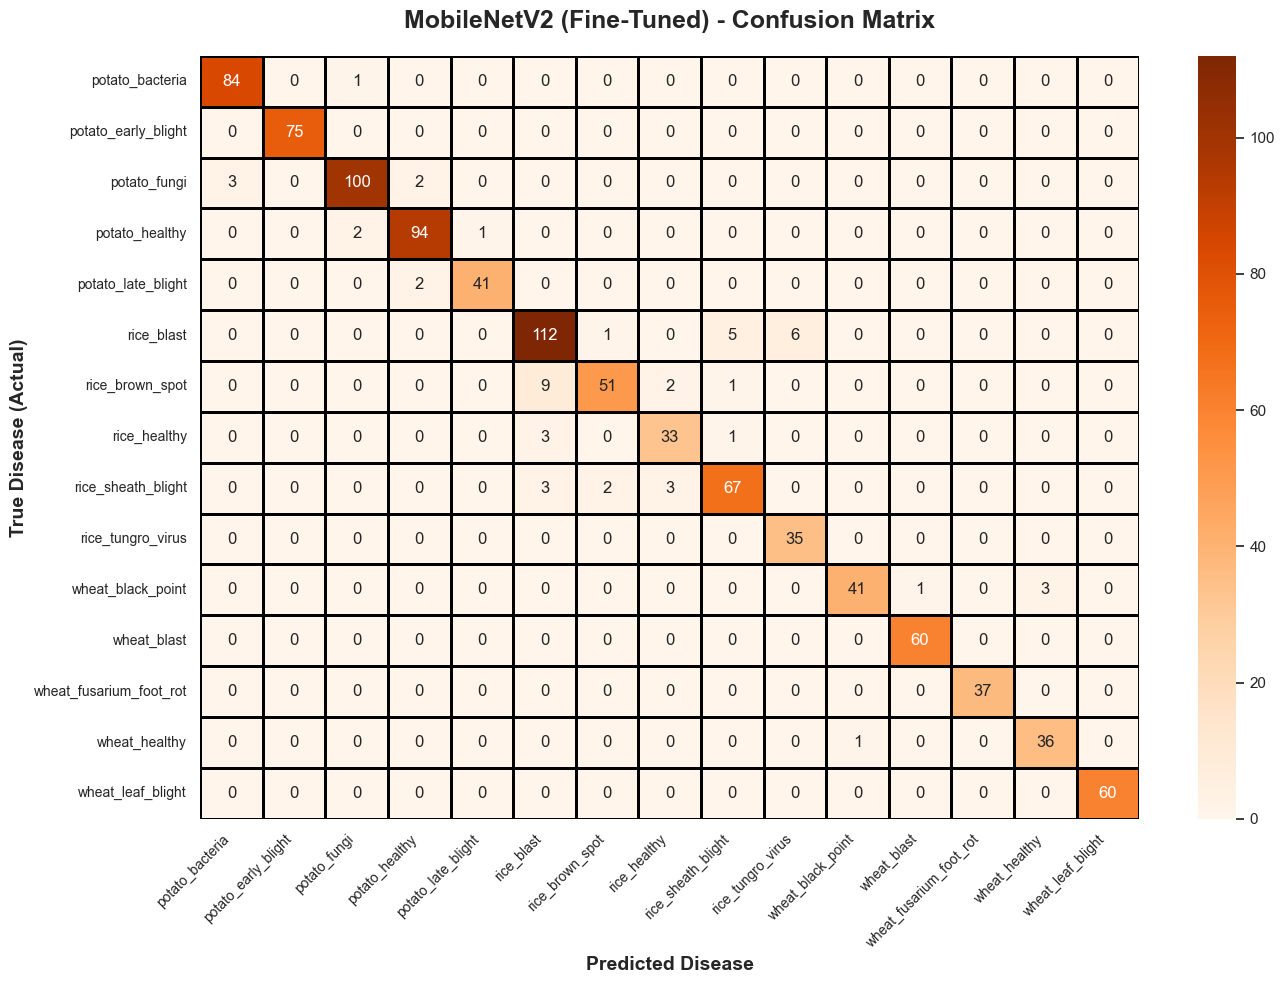

✅ MobileNetV2 Evaluation Complete! Save this chart to your thesis folder.


In [7]:
# ==========================================
# CELL #9 - MOBILENETV2 EVALUATION & MATRIX
# ==========================================
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix

print("🧹 Flushing GPU Memory for Evaluation...")
tf.keras.backend.clear_session()

# 1. LOAD THE FINE-TUNED MOBILENET MODEL
FINAL_DIR = r"D:\Final_Experiment"
model_path = os.path.join(FINAL_DIR, "MobileNetV2_FineTuned.keras")

print(f"🔍 Loading Model: {model_path}")
eval_model = load_model(model_path)

# 2. CALCULATE 2-DECIMAL ACCURACY
print("\n📊 Running standard evaluation...")
loss, accuracy = eval_model.evaluate(val_gen, verbose=1)
print(f"\n🏆 MOBILENETV2 FINAL ACCURACY: {accuracy * 100:.2f}%")

# 3. GENERATE PREDICTIONS FOR THE CONFUSION MATRIX
print("\n🕵️‍♂️ Generating predictions for the Confusion Matrix...")
# Reset generator to ensure it starts from the very first image
val_gen.reset() 
predictions = eval_model.predict(val_gen, verbose=1)

# Convert probabilities to actual class indices (0 to 14)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = val_gen.classes
class_labels = list(val_gen.class_indices.keys())

# 4. PRINT CLASSIFICATION REPORT (Precision, Recall, F1-Score)
print("\n📄 --- CLASSIFICATION REPORT ---")
report = classification_report(true_classes, predicted_classes, target_names=class_labels)
print(report)

# 5. PLOT THE CONFUSION MATRIX
print("\n🎨 Plotting Confusion Matrix...")
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(14, 10))
sns.set_theme(style="whitegrid") 

# Create the heatmap
heatmap = sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', # Changed to Oranges to easily distinguish from DenseNet's Blue chart in your thesis!
                      xticklabels=class_labels, 
                      yticklabels=class_labels,
                      linewidths=1, linecolor='black')

# Formatting for thesis-level professionalism
plt.title('MobileNetV2 (Fine-Tuned) - Confusion Matrix', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Predicted Disease', fontsize=14, fontweight='bold')
plt.ylabel('True Disease (Actual)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

print("✅ MobileNetV2 Evaluation Complete! Save this chart to your thesis folder.")

In [9]:
# ==========================================
# CELL #10 - PHASE 1: EFFICIENTNETB0 (FEATURE EXTRACTION)
# ==========================================
import os
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

print("🧹 Flushing GPU Memory...")
tf.keras.backend.clear_session() 

print("🏗️ Building Phase 1: EfficientNetB0 Feature Extractor...\n")

# 1. THE RAW INPUT GATE
inputs = Input(shape=(224, 224, 3), name="raw_image_input")

# 2. THE BASE MODEL (Frozen)
base_efficient = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_efficient.trainable = False # 🔒 STRICTLY FROZEN FOR PHASE 1

# Pass RAW inputs directly into the base model
x = base_efficient(inputs, training=False) 

# 3. THE CUSTOM 15-CLASS HEAD
x = GlobalAveragePooling2D(name="global_pooling")(x)
x = Dropout(0.3, name="head_dropout")(x) 
outputs = Dense(15, activation='softmax', name="final_predictions")(x)

# Assemble
efficient_phase1 = Model(inputs=inputs, outputs=outputs, name="EfficientNet_Phase1_Base")

# 4. COMPILE 
efficient_phase1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

efficient_phase1.summary()

# 5. ISOLATED DIRECTORY & CALLBACKS
FINAL_DIR = r"D:\Final_Experiment"
os.makedirs(FINAL_DIR, exist_ok=True)
model_path = os.path.join(FINAL_DIR, "EfficientNetB0_Base.keras")

callbacks = [
    # 🚨 THE FIX: save_weights_only=True prevents the EagerTensor JSON crash!
    ModelCheckpoint(model_path, monitor='val_accuracy', save_best_only=True, mode='max', save_weights_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

# 6. TRAIN ONLY THE HEAD
print("\n🚀 Starting Phase 1 Training for EfficientNetB0...")
history_eff_p1 = efficient_phase1.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25, 
    class_weight=class_weight_dict,
    callbacks=callbacks
)

print(f"\n✅ Phase 1 Complete! Base weights safely isolated at: {model_path}")

🧹 Flushing GPU Memory...
🏗️ Building Phase 1: EfficientNetB0 Feature Extractor...

Model: "EfficientNet_Phase1_Base"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 raw_image_input (InputLayer  [(None, 224, 224, 3)]    0         
 )                                                               
                                                                 
 efficientnetb0 (Functional)  (None, 7, 7, 1280)       4049571   
                                                                 
 global_pooling (GlobalAvera  (None, 1280)             0         
 gePooling2D)                                                    
                                                                 
 head_dropout (Dropout)      (None, 1280)              0         
                                                                 
 final_predictions (Dense)   (None, 15)                19215     
                         

In [10]:
# ==========================================
# CELL #11 - PHASE 2: EFFICIENTNETB0 (FINE-TUNING)
# ==========================================
import os
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

print("🧹 Flushing GPU Memory for Fine-Tuning...")
tf.keras.backend.clear_session() 

print("🏗️ Rebuilding the EfficientNetB0 Skeleton...\n")

# 1. REBUILD THE EXACT SKELETON FROM PHASE 1
inputs = Input(shape=(224, 224, 3), name="raw_image_input")
# We use weights=None because we are about to load our own!
base_efficient = EfficientNetB0(weights=None, include_top=False, input_shape=(224, 224, 3))
x = base_efficient(inputs, training=False) 
x = GlobalAveragePooling2D(name="global_pooling")(x)
x = Dropout(0.3, name="head_dropout")(x) 
outputs = Dense(15, activation='softmax', name="final_predictions")(x)

efficient_finetune = Model(inputs=inputs, outputs=outputs, name="EfficientNet_Phase2")

# 2. LOAD THE MEMORIES (WEIGHTS) FROM PHASE 1
FINAL_DIR = r"D:\Final_Experiment"
phase1_path = os.path.join(FINAL_DIR, "EfficientNetB0_Base.keras")

print("🧠 Pouring Phase 1 weights into the skeleton...")
efficient_finetune.load_weights(phase1_path)

# 3. LOCATE BASE MODEL AND PERFORM BRAIN SURGERY
# Using our dynamic locator just to be safe!
base_layer = next(layer for layer in efficient_finetune.layers if isinstance(layer, tf.keras.models.Model))
print(f"🎯 Successfully located base model: {base_layer.name}")

# Unfreeze the base entirely
base_layer.trainable = True 

# Keep early layers locked, open the last 50
print("🔬 Performing Surgical Unfreeze (Unlocking last 50 layers)...")
for layer in base_layer.layers[:-50]:
    layer.trainable = False

trainable_count = sum([1 for w in efficient_finetune.trainable_weights])
print(f"✅ Ready! {trainable_count} weight tensors are now unlocked for training.")

# 4. RECOMPILE WITH MICROSCOPIC LEARNING RATE
efficient_finetune.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 5. CALLBACKS (Remember: We must STILL save weights only!)
finetuned_path = os.path.join(FINAL_DIR, "EfficientNetB0_FineTuned.keras")

callbacks_ft = [
    ModelCheckpoint(finetuned_path, monitor='val_accuracy', save_best_only=True, mode='max', save_weights_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1) 
]

# 6. COMMENCE FINE-TUNING
print("\n🚀 Starting Phase 2 Training (EfficientNetB0 Fine-Tuning)...")
history_eff_ft = efficient_finetune.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20, 
    class_weight=class_weight_dict,
    callbacks=callbacks_ft
)

print(f"\n👑 Phase 2 Complete! EfficientNetB0 is fully specialized. Weights saved at: {finetuned_path}")

🧹 Flushing GPU Memory for Fine-Tuning...
🏗️ Rebuilding the EfficientNetB0 Skeleton...

🧠 Pouring Phase 1 weights into the skeleton...


ValueError: axes don't match array

In [11]:
# ==========================================
# CELL #10 - PHASE 1: EFFICIENTNETB0 (FEATURE EXTRACTION)
# ==========================================
import os
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

print("🧹 Flushing GPU Memory...")
tf.keras.backend.clear_session() 

print("🏗️ Building Phase 1: EfficientNetB0 Feature Extractor...\n")

inputs = Input(shape=(224, 224, 3), name="raw_image_input")
base_efficient = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_efficient.trainable = False 

x = base_efficient(inputs, training=False) 
x = GlobalAveragePooling2D(name="global_pooling")(x)
x = Dropout(0.3, name="head_dropout")(x) 
outputs = Dense(15, activation='softmax', name="final_predictions")(x)

efficient_phase1 = Model(inputs=inputs, outputs=outputs, name="EfficientNet_Phase1_Base")

efficient_phase1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 🚨 THE FIX: No .keras extension! This saves it as a robust TensorFlow Directory.
FINAL_DIR = r"D:\Final_Experiment"
os.makedirs(FINAL_DIR, exist_ok=True)
model_path = os.path.join(FINAL_DIR, "EfficientNetB0_Base") # <-- Changed here!

callbacks = [
    ModelCheckpoint(model_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

print("\n🚀 Starting Phase 1 Training for EfficientNetB0...")
history_eff_p1 = efficient_phase1.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25, 
    class_weight=class_weight_dict,
    callbacks=callbacks
)

print(f"\n✅ Phase 1 Complete! Full model safely saved to directory: {model_path}")

🧹 Flushing GPU Memory...
🏗️ Building Phase 1: EfficientNetB0 Feature Extractor...


🚀 Starting Phase 1 Training for EfficientNetB0...
Epoch 1/25
287/287 [==============================] - ETA: 0s - loss: 0.9016 - accuracy: 0.6990
Epoch 1: val_accuracy improved from -inf to 0.85072, saving model to D:\Final_Experiment\EfficientNetB0_Base


INFO:tensorflow:Assets written to: D:\Final_Experiment\EfficientNetB0_Base\assets


INFO:tensorflow:Assets written to: D:\Final_Experiment\EfficientNetB0_Base\assets


TypeError: Unable to serialize [2.0896919 2.1128857 2.1081853] to JSON. Unrecognized type <class 'tensorflow.python.framework.ops.EagerTensor'>.

In [12]:
# ==========================================
# CELL #10 - PHASE 1: EFFICIENTNETB0 (FEATURE EXTRACTION)
# ==========================================
import os
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

print("🧹 Flushing GPU Memory...")
tf.keras.backend.clear_session() 

print("🏗️ Building Phase 1: EfficientNetB0 Feature Extractor...\n")

inputs = Input(shape=(224, 224, 3), name="raw_image_input")
base_efficient = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_efficient.trainable = False 

x = base_efficient(inputs, training=False) 
x = GlobalAveragePooling2D(name="global_pooling")(x)
x = Dropout(0.3, name="head_dropout")(x) 
outputs = Dense(15, activation='softmax', name="final_predictions")(x)

efficient_phase1 = Model(inputs=inputs, outputs=outputs, name="EfficientNet_Phase1_Base")

efficient_phase1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 🚨 THE FIX: Save explicitly as .h5 weights!
FINAL_DIR = r"D:\Final_Experiment"
os.makedirs(FINAL_DIR, exist_ok=True)
model_path = os.path.join(FINAL_DIR, "EfficientNetB0_Base_Weights.h5")

callbacks = [
    ModelCheckpoint(model_path, monitor='val_accuracy', save_best_only=True, mode='max', save_weights_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

print("\n🚀 Starting Phase 1 Training for EfficientNetB0...")
history_eff_p1 = efficient_phase1.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25, 
    class_weight=class_weight_dict,
    callbacks=callbacks
)

print(f"\n✅ Phase 1 Complete! Weights safely saved to: {model_path}")

🧹 Flushing GPU Memory...
🏗️ Building Phase 1: EfficientNetB0 Feature Extractor...


🚀 Starting Phase 1 Training for EfficientNetB0...
Epoch 1/25
287/287 [==============================] - ETA: 0s - loss: 0.9123 - accuracy: 0.6926
Epoch 1: val_accuracy improved from -inf to 0.84356, saving model to D:\Final_Experiment\EfficientNetB0_Base_Weights.h5
287/287 [==============================] - 188s 613ms/step - loss: 0.9123 - accuracy: 0.6926 - val_loss: 0.5351 - val_accuracy: 0.8436 - lr: 0.0010
Epoch 2/25
287/287 [==============================] - ETA: 0s - loss: 0.4074 - accuracy: 0.8638
Epoch 2: val_accuracy improved from 0.84356 to 0.87219, saving model to D:\Final_Experiment\EfficientNetB0_Base_Weights.h5
287/287 [==============================] - 166s 579ms/step - loss: 0.4074 - accuracy: 0.8638 - val_loss: 0.4038 - val_accuracy: 0.8722 - lr: 0.0010
Epoch 3/25
287/287 [==============================] - ETA: 0s - loss: 0.3308 - accuracy: 0.8764
Epoch 3: val_accuracy improved from 0.8

In [13]:
# ==========================================
# CELL #11 - PHASE 2: EFFICIENTNETB0 (FINE-TUNING)
# ==========================================
import os
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

print("🧹 Flushing GPU Memory for Fine-Tuning...")
tf.keras.backend.clear_session() 

print("🏗️ Rebuilding the Perfect Skeleton...\n")

# 1. REBUILD USING 'imagenet' TO ENSURE PERFECT ALIGNMENT
inputs = Input(shape=(224, 224, 3), name="raw_image_input")
base_efficient = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
x = base_efficient(inputs, training=False) 
x = GlobalAveragePooling2D(name="global_pooling")(x)
x = Dropout(0.3, name="head_dropout")(x) 
outputs = Dense(15, activation='softmax', name="final_predictions")(x)

efficient_finetune = Model(inputs=inputs, outputs=outputs, name="EfficientNet_Phase2")

# 2. LOAD YOUR PHASE 1 WEIGHTS (Overwriting the ImageNet math)
FINAL_DIR = r"D:\Final_Experiment"
phase1_path = os.path.join(FINAL_DIR, "EfficientNetB0_Base_Weights.h5")

print("🧠 Pouring Phase 1 weights into the perfect skeleton...")
efficient_finetune.load_weights(phase1_path)

# 3. LOCATE BASE MODEL AND PERFORM BRAIN SURGERY
base_layer = next(layer for layer in efficient_finetune.layers if isinstance(layer, tf.keras.models.Model))
base_layer.trainable = True 

print("🔬 Performing Surgical Unfreeze (Unlocking last 50 layers)...")
for layer in base_layer.layers[:-50]:
    layer.trainable = False

trainable_count = sum([1 for w in efficient_finetune.trainable_weights])
print(f"✅ Ready! {trainable_count} weight tensors are now unlocked for training.")

# 4. RECOMPILE WITH MICROSCOPIC LEARNING RATE
efficient_finetune.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 5. CALLBACKS (Save fine-tuned weights as .h5 too!)
finetuned_path = os.path.join(FINAL_DIR, "EfficientNetB0_FineTuned_Weights.h5")

callbacks_ft = [
    ModelCheckpoint(finetuned_path, monitor='val_accuracy', save_best_only=True, mode='max', save_weights_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1) 
]

# 6. COMMENCE FINE-TUNING
print("\n🚀 Starting Phase 2 Training (EfficientNetB0 Fine-Tuning)...")
history_eff_ft = efficient_finetune.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20, 
    class_weight=class_weight_dict,
    callbacks=callbacks_ft
)

print(f"\n👑 Phase 2 Complete! Weights safely saved to: {finetuned_path}")

🧹 Flushing GPU Memory for Fine-Tuning...
🏗️ Rebuilding the Perfect Skeleton...

🧠 Pouring Phase 1 weights into the perfect skeleton...


ValueError: axes don't match array

In [14]:
# ==========================================
# CELL #10/11 - EFFICIENTNET MASTER PIPELINE
# (Phase 1 & Phase 2 Continuous Training)
# ==========================================
import os
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

print("🧹 Flushing GPU Memory for Master Pipeline...")
tf.keras.backend.clear_session() 

print("🏗️ Building EfficientNetB0 Architecture...\n")

# 1. BUILD THE ARCHITECTURE (Just Once!)
inputs = Input(shape=(224, 224, 3), name="raw_image_input")
base_efficient = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
x = base_efficient(inputs, training=False) 
x = GlobalAveragePooling2D(name="global_pooling")(x)
x = Dropout(0.3, name="head_dropout")(x) 
outputs = Dense(15, activation='softmax', name="final_predictions")(x)

efficient_master = Model(inputs=inputs, outputs=outputs, name="EfficientNet_Master")

# ==========================================
# PHASE 1: FEATURE EXTRACTION (Frozen Base)
# ==========================================
print("\n🚀 --- STARTING PHASE 1: FEATURE EXTRACTION ---")
base_efficient.trainable = False # Freeze base

efficient_master.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# We use EarlyStopping to catch the best moment, but we don't save to the hard drive yet!
callbacks_p1 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
]

history_eff_p1 = efficient_master.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15, 
    class_weight=class_weight_dict,
    callbacks=callbacks_p1
)
print("✅ Phase 1 Complete! Best weights restored in RAM.")

# ==========================================
# PHASE 2: BRAIN SURGERY (Fine-Tuning)
# ==========================================
print("\n🔓 --- STARTING PHASE 2: BRAIN SURGERY ---")
base_efficient.trainable = True # Unlock base

# Lock everything except top 50
for layer in base_efficient.layers[:-50]:
    layer.trainable = False

trainable_count = sum([1 for w in efficient_master.trainable_weights])
print(f"🔬 Unlocked {trainable_count} weight tensors for fine-tuning.")

# Recompile with microscopic learning rate
efficient_master.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# NOW we save the final result to the hard drive as weights to prevent all bugs
FINAL_DIR = r"D:\Final_Experiment"
os.makedirs(FINAL_DIR, exist_ok=True)
final_weights_path = os.path.join(FINAL_DIR, "EfficientNetB0_Final_Weights.h5")

callbacks_p2 = [
    ModelCheckpoint(final_weights_path, monitor='val_accuracy', save_best_only=True, mode='max', save_weights_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1) 
]

history_eff_p2 = efficient_master.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20, 
    class_weight=class_weight_dict,
    callbacks=callbacks_p2
)

print(f"\n👑 EFFICIENTNET MASTERPIECE COMPLETE! Final weights safely saved at: {final_weights_path}")

🧹 Flushing GPU Memory for Master Pipeline...
🏗️ Building EfficientNetB0 Architecture...


🚀 --- STARTING PHASE 1: FEATURE EXTRACTION ---
Epoch 1/15
287/287 [==============================] - 186s 607ms/step - loss: 0.8797 - accuracy: 0.7132 - val_loss: 0.4697 - val_accuracy: 0.8599
Epoch 2/15
287/287 [==============================] - 164s 571ms/step - loss: 0.4084 - accuracy: 0.8585 - val_loss: 0.3777 - val_accuracy: 0.8753
Epoch 3/15
287/287 [==============================] - 163s 568ms/step - loss: 0.3220 - accuracy: 0.8810 - val_loss: 0.3251 - val_accuracy: 0.8957
Epoch 4/15
287/287 [==============================] - 162s 563ms/step - loss: 0.2764 - accuracy: 0.8974 - val_loss: 0.3022 - val_accuracy: 0.9070
Epoch 5/15
287/287 [==============================] - 163s 568ms/step - loss: 0.2609 - accuracy: 0.8998 - val_loss: 0.2700 - val_accuracy: 0.9192
Epoch 6/15
287/287 [==============================] - 161s 561ms/step - loss: 0.2348 - accuracy: 0.9120 - val_loss: 0.2589 - val_accu

In [15]:
# ==========================================
# CELL #12 - EFFICIENTNETB0 EVALUATION & MATRIX
# ==========================================
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from sklearn.metrics import classification_report, confusion_matrix

print("🧹 Flushing GPU Memory for Evaluation...")
tf.keras.backend.clear_session()

print("🏗️ Rebuilding EfficientNetB0 Skeleton for Evaluation...\n")

# 1. REBUILD THE EXACT ARCHITECTURE SKELETON
inputs = Input(shape=(224, 224, 3), name="raw_image_input")
# weights=None is safe here because we are immediately loading our .h5 file over it
base_efficient = EfficientNetB0(weights=None, include_top=False, input_shape=(224, 224, 3))
x = base_efficient(inputs, training=False) 
x = GlobalAveragePooling2D(name="global_pooling")(x)
x = Dropout(0.3, name="head_dropout")(x) 
outputs = Dense(15, activation='softmax', name="final_predictions")(x)

eval_model = Model(inputs=inputs, outputs=outputs, name="EfficientNet_Evaluation")

# 2. LOAD THE FINAL FINE-TUNED WEIGHTS
FINAL_DIR = r"D:\Final_Experiment"
weights_path = os.path.join(FINAL_DIR, "EfficientNetB0_Final_Weights.h5")

print(f"🧠 Loading Final Weights from: {weights_path}")
eval_model.load_weights(weights_path)

# 3. COMPILE THE MODEL
eval_model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. CALCULATE 2-DECIMAL ACCURACY
print("\n📊 Running standard evaluation...")
loss, accuracy = eval_model.evaluate(val_gen, verbose=1)
print(f"\n🏆 EFFICIENTNETB0 FINAL ACCURACY: {accuracy * 100:.2f}%")

# 5. GENERATE PREDICTIONS FOR THE CONFUSION MATRIX
print("\n🕵️‍♂️ Generating predictions for the Confusion Matrix...")
val_gen.reset() # Standard safety reset
predictions = eval_model.predict(val_gen, verbose=1)

# Convert probabilities to actual class indices (0 to 14)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = val_gen.classes
class_labels = list(val_gen.class_indices.keys())

# 6. PRINT CLASSIFICATION REPORT (Precision, Recall, F1-Score)
print("\n📄 --- CLASSIFICATION REPORT ---")
report = classification_report(true_classes, predicted_classes, target_names=class_labels)
print(report)

# 7. PLOT THE CONFUSION MATRIX
print("\n🎨 Plotting Confusion Matrix...")
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(14, 10))
sns.set_theme(style="whitegrid") 

# Using 'Purples' for EfficientNet to keep your thesis charts beautifully color-coded!
heatmap = sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
                      xticklabels=class_labels, 
                      yticklabels=class_labels,
                      linewidths=1, linecolor='black')

# Formatting for thesis-level professionalism
plt.title('EfficientNetB0 (Fine-Tuned) - Confusion Matrix', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Predicted Disease', fontsize=14, fontweight='bold')
plt.ylabel('True Disease (Actual)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

print("✅ EfficientNetB0 Evaluation Complete! Save this purple chart to your thesis folder.")

🧹 Flushing GPU Memory for Evaluation...
🏗️ Rebuilding EfficientNetB0 Skeleton for Evaluation...

🧠 Loading Final Weights from: D:\Final_Experiment\EfficientNetB0_Final_Weights.h5


ValueError: axes don't match array

🧠 Bypassing hard drive and evaluating the model directly from RAM...

📊 Running standard evaluation...
62/62 [==============================] - 23s 313ms/step - loss: 0.1660 - accuracy: 0.9407

🏆 EFFICIENTNETB0 FINAL ACCURACY: 94.07%

🕵️‍♂️ Generating predictions for the Confusion Matrix...
62/62 [==============================] - 25s 298ms/step

📄 --- CLASSIFICATION REPORT ---
                         precision    recall  f1-score   support

        potato_bacteria       0.92      0.98      0.95        85
    potato_early_blight       1.00      1.00      1.00        75
           potato_fungi       0.97      0.90      0.94       105
         potato_healthy       0.97      0.97      0.97        97
     potato_late_blight       0.96      1.00      0.98        43
             rice_blast       0.89      0.86      0.88       124
        rice_brown_spot       0.79      0.90      0.84        63
           rice_healthy       0.87      0.89      0.88        37
     rice_sheath_blight       0.9

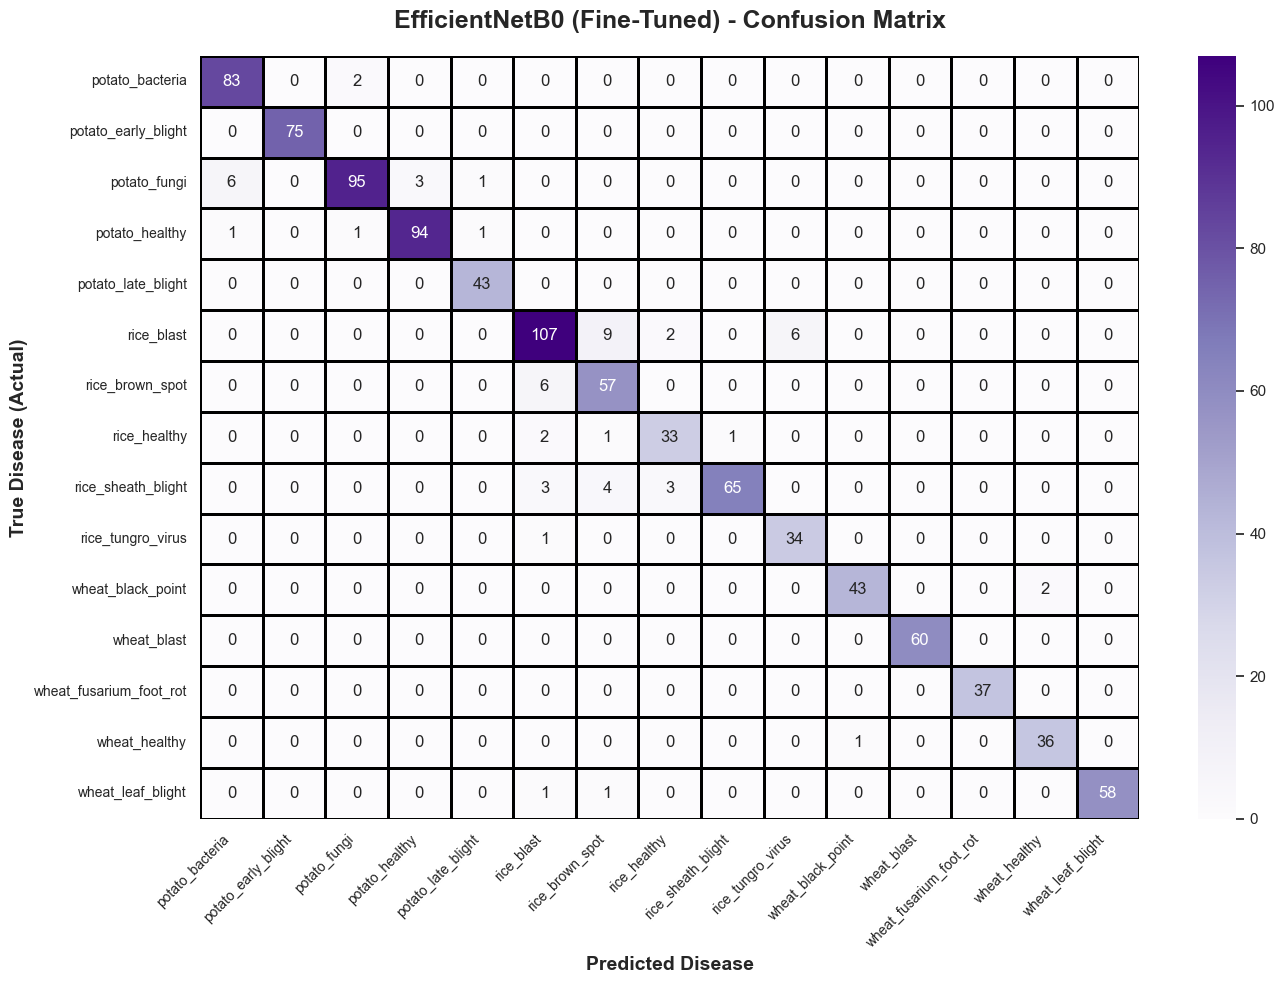


✅ Evaluation Complete! Safe TF weights saved to: D:\Final_Experiment\EfficientNetB0_TF_Weights


In [17]:
# ==========================================
# CELL #12 - EFFICIENTNETB0 EVALUATION (RAM BYPASS)
# ==========================================
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("🧠 Bypassing hard drive and evaluating the model directly from RAM...\n")

# 1. EVALUATE DIRECTLY USING 'efficient_master'
print("📊 Running standard evaluation...")
loss, accuracy = efficient_master.evaluate(val_gen, verbose=1)
print(f"\n🏆 EFFICIENTNETB0 FINAL ACCURACY: {accuracy * 100:.2f}%")

# 2. GENERATE PREDICTIONS
print("\n🕵️‍♂️ Generating predictions for the Confusion Matrix...")
val_gen.reset() # Standard safety reset
predictions = efficient_master.predict(val_gen, verbose=1)

# Convert probabilities to actual class indices (0 to 14)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = val_gen.classes
class_labels = list(val_gen.class_indices.keys())

# 3. PRINT CLASSIFICATION REPORT (Precision, Recall, F1-Score)
print("\n📄 --- CLASSIFICATION REPORT ---")
report = classification_report(true_classes, predicted_classes, target_names=class_labels)
print(report)

# 4. PLOT THE CONFUSION MATRIX
print("\n🎨 Plotting Confusion Matrix...")
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(14, 10))
sns.set_theme(style="whitegrid") 

# Using 'Purples' for EfficientNet
heatmap = sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
                      xticklabels=class_labels, 
                      yticklabels=class_labels,
                      linewidths=1, linecolor='black')

# Formatting for thesis-level professionalism
plt.title('EfficientNetB0 (Fine-Tuned) - Confusion Matrix', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Predicted Disease', fontsize=14, fontweight='bold')
plt.ylabel('True Disease (Actual)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

# 5. SAVE WEIGHTS IN NATIVE TENSORFLOW FORMAT (Future-proofing)
# This saves a folder instead of an .h5 file, bypassing the reading bug entirely!
FINAL_DIR = r"D:\Final_Experiment"
tf_weights_path = os.path.join(FINAL_DIR, "EfficientNetB0_TF_Weights")
efficient_master.save_weights(tf_weights_path, save_format='tf')
print(f"\n✅ Evaluation Complete! Safe TF weights saved to: {tf_weights_path}")

🧹 Flushing GPU Memory for True Evaluation...

📁 Loading Unseen Test Data...
Found 992 images belonging to 15 classes.

🕵️‍♂️ Evaluating Detective 1: DenseNet121 on Test Set...
✅ DenseNet121 Test Accuracy: 92.54%

🕵️‍♂️ Evaluating Detective 2: MobileNetV2 on Test Set...
✅ MobileNetV2 Test Accuracy: 93.65%

🕵️‍♂️ Evaluating Detective 3: EfficientNetB0 on Test Set...


✅ EfficientNetB0 Test Accuracy: 93.25%

🎨 Generating Comparative Bar Chart (Test Set)...


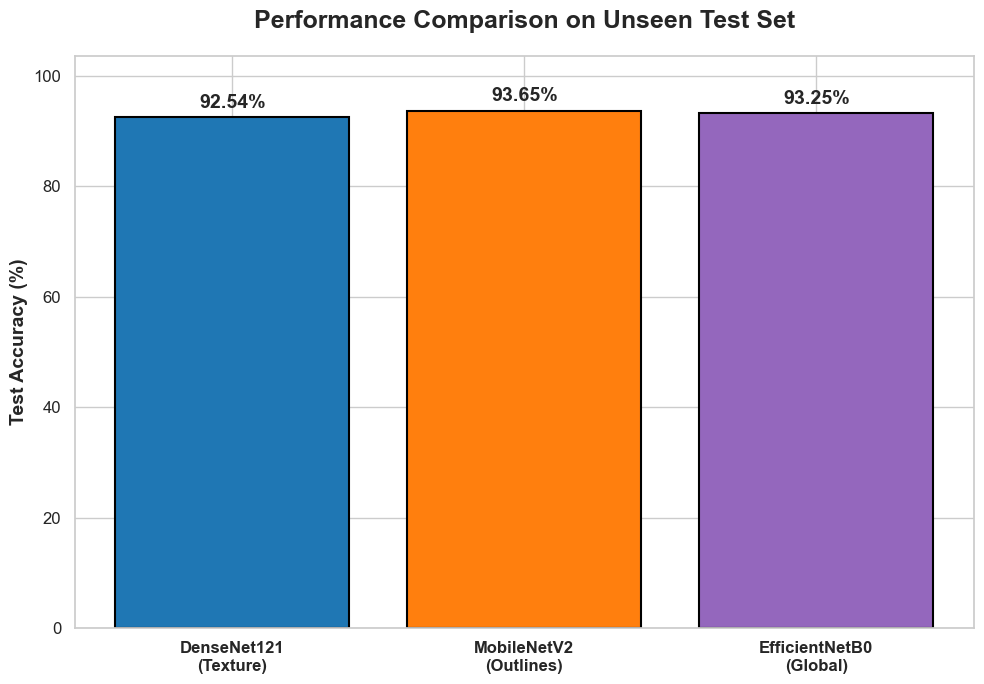

✅ True Comparison Complete! Save this chart for your thesis.


In [19]:
# ==========================================
# CELL #13 - TRUE TEST SET COMPARATIVE ANALYSIS
# ==========================================
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("🧹 Flushing GPU Memory for True Evaluation...\n")
tf.keras.backend.clear_session()

FINAL_DIR = r"D:\Final_Experiment"
accuracies = []
model_names = ['DenseNet121\n(Texture)', 'MobileNetV2\n(Outlines)', 'EfficientNetB0\n(Global)']

# ---------------------------------------------------------
# 0. LOAD THE UNSEEN TEST DATA (The Final Exam)
# ---------------------------------------------------------
print("📁 Loading Unseen Test Data...")
# We use a clean, unaugmented generator for the test set
test_datagen = ImageDataGenerator() 
test_gen = test_datagen.flow_from_directory(
    r"D:\MasterDataset\test",
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    shuffle=False, # Must be False to match labels perfectly
    seed=42
)

# ---------------------------------------------------------
# 1. EVALUATE DENSENET121
# ---------------------------------------------------------
print("\n🕵️‍♂️ Evaluating Detective 1: DenseNet121 on Test Set...")
dense_path = os.path.join(FINAL_DIR, "DenseNet121_FineTuned.keras")
model_dense = load_model(dense_path)
loss, acc = model_dense.evaluate(test_gen, verbose=0)
accuracies.append(acc * 100)
print(f"✅ DenseNet121 Test Accuracy: {acc * 100:.2f}%")
del model_dense 
tf.keras.backend.clear_session()

# ---------------------------------------------------------
# 2. EVALUATE MOBILENETV2
# ---------------------------------------------------------
print("\n🕵️‍♂️ Evaluating Detective 2: MobileNetV2 on Test Set...")
mobile_path = os.path.join(FINAL_DIR, "MobileNetV2_FineTuned.keras")
model_mobile = load_model(mobile_path)
loss, acc = model_mobile.evaluate(test_gen, verbose=0)
accuracies.append(acc * 100)
print(f"✅ MobileNetV2 Test Accuracy: {acc * 100:.2f}%")
del model_mobile
tf.keras.backend.clear_session()

# ---------------------------------------------------------
# 3. EVALUATE EFFICIENTNETB0 (THE FIX)
# ---------------------------------------------------------
print("\n🕵️‍♂️ Evaluating Detective 3: EfficientNetB0 on Test Set...")

# THE FIX: Use 'imagenet' to ensure perfect architectural alignment!
inputs = Input(shape=(224, 224, 3), name="raw_image_input")
base_eff = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
x = base_eff(inputs, training=False)
x = GlobalAveragePooling2D(name="global_pooling")(x)
x = Dropout(0.3, name="head_dropout")(x)
outputs = Dense(15, activation='softmax', name="final_predictions")(x)
model_eff = Model(inputs=inputs, outputs=outputs)

# Load your perfectly saved TF weights over the aligned skeleton
eff_path = os.path.join(FINAL_DIR, "EfficientNetB0_TF_Weights")
model_eff.load_weights(eff_path)
model_eff.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

loss, acc = model_eff.evaluate(test_gen, verbose=0)
accuracies.append(acc * 100)
print(f"✅ EfficientNetB0 Test Accuracy: {acc * 100:.2f}%")
del model_eff
tf.keras.backend.clear_session()

# ---------------------------------------------------------
# 4. PLOT THE THESIS-READY BAR CHART
# ---------------------------------------------------------
print("\n🎨 Generating Comparative Bar Chart (Test Set)...")
plt.figure(figsize=(10, 7))
sns.set_theme(style="whitegrid")

colors = ['#1f77b4', '#ff7f0e', '#9467bd']
bars = plt.bar(model_names, accuracies, color=colors, edgecolor='black', linewidth=1.5)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.2f}%', 
             ha='center', va='bottom', fontsize=14, fontweight='bold')

plt.ylim(0, max(accuracies) + 10) 
plt.title('Performance Comparison on Unseen Test Set', fontsize=18, fontweight='bold', pad=20)
plt.ylabel('Test Accuracy (%)', fontsize=14, fontweight='bold')
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

print("✅ True Comparison Complete! Save this chart for your thesis.")

In [16]:
print(train_gen.batch_size)

16


In [2]:
# ==========================================
# CELL #3 - THE UPGRADED UNIFIED DATA PIPELINE
# ==========================================
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight

print("⚙️ Building the Upgraded Unified Data Pipeline...\n")

# 🚨 THE FIX: Lowered to 8 to survive the 4GB VRAM Wall!
BATCH_SIZE = 8 
IMG_SIZE = (224, 224)

# 1. THE SINGLE MASTER GENERATOR (UNSCALED BUT HIGHLY AUGMENTED)
# CRITICAL: No rescale=1./255! We must keep raw pixels for EfficientNet.
master_train_datagen = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    shear_range=0.1,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode='nearest'
)
master_val_datagen = ImageDataGenerator() # Clean, unscaled validation

# 2. FLOW FROM DIRECTORY (USING OUR LOCKED SEED)
print("Loading Training Data...")
train_gen = master_train_datagen.flow_from_directory(
    r"D:\MasterDataset\train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42  # <- Locked for the Master Experiment
)

print("Loading Validation Data...")
val_gen = master_val_datagen.flow_from_directory(
    r"D:\MasterDataset\val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=42
)

# 3. CALCULATE CLASS WEIGHTS
print("\n⚖️ Calculating Class Weights for Imbalanced Data...")
train_classes = train_gen.classes
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_classes),
    y=train_classes
)

# Convert to a dictionary and force float types to prevent TF JSON errors
class_weight_dict = {int(k): float(v) for k, v in enumerate(class_weights_array)}

print("✅ Upgraded Unified Data Pipeline is Ready!")

⚙️ Building the Upgraded Unified Data Pipeline...

Loading Training Data...
Found 4581 images belonging to 15 classes.
Loading Validation Data...
Found 978 images belonging to 15 classes.

⚖️ Calculating Class Weights for Imbalanced Data...
✅ Upgraded Unified Data Pipeline is Ready!


In [3]:
# ==========================================
# CELL #28 - THE TRUE "THREE FUSION" BOSS MODEL
# ==========================================
import os
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Concatenate, Dense, Dropout
from tensorflow.keras.layers import Rescaling, GlobalAveragePooling2D
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

print("🧹 Flushing GPU Memory for the Final Build...")
tf.keras.backend.clear_session()
FINAL_DIR = r"D:\Final_Experiment"

print("🏛️ Assembling The Three Fusion Model...\n")

# ------------------------------------------
# 1. THE UNIFIED INPUT GATE
# ------------------------------------------
# Accepts raw 0-255 pixels directly from the Cell #3 Generators
unified_input = Input(shape=(224, 224, 3), name="master_input")

# Internal scaler for DenseNet and MobileNet (EfficientNet skips this!)
scaled_input = Rescaling(1./255, name="internal_scaler")(unified_input) 

# ------------------------------------------
# 2. LOAD & LOBOTOMIZE THE FINE-TUNED DETECTIVES
# ------------------------------------------
print("🧠 Extracting brains from Fine-Tuned Detectives...")

# Detective #1: DenseNet121 (Uses Scaled Input)
print("   -> Loading DenseNet121...")
dense_full = load_model(os.path.join(FINAL_DIR, "DenseNet121_FineTuned.keras"))
dense_extractor = Model(
    inputs=dense_full.input, 
    outputs=dense_full.get_layer("global_pooling").output, 
    name="dense_branch"
)
dense_extractor.trainable = False # 🔒 FREEZE!
feat_dense = dense_extractor(scaled_input)

# Detective #2: MobileNetV2 (Uses Scaled Input)
print("   -> Loading MobileNetV2...")
mobile_full = load_model(os.path.join(FINAL_DIR, "MobileNetV2_FineTuned.keras"))
mobile_extractor = Model(
    inputs=mobile_full.input, 
    outputs=mobile_full.get_layer("global_pooling").output, 
    name="mobile_branch"
)
mobile_extractor.trainable = False # 🔒 FREEZE!
feat_mobile = mobile_extractor(scaled_input)

# Detective #3: EfficientNetB0 (Uses RAW Input)
# Rebuilding skeleton to avoid the EagerTensor JSON bug on load
print("   -> Loading EfficientNetB0...")
eff_base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
x_eff = eff_base(unified_input, training=False)
feat_eff = GlobalAveragePooling2D(name="eff_global_pooling")(x_eff)

# Create a temporary model to load the saved TF weights
temp_eff_model = Model(inputs=unified_input, outputs=feat_eff)
# We load just the weights to bypass any metadata crashes
temp_eff_model.load_weights(os.path.join(FINAL_DIR, "EfficientNetB0_TF_Weights")).expect_partial()
temp_eff_model.trainable = False # 🔒 FREEZE!
feat_eff_final = temp_eff_model(unified_input)

# ------------------------------------------
# 3. THE BOARDROOM & THE CEO
# ------------------------------------------
print("\n💼 Building the CEO Layer...")

# Merging the features (1024 + 1280 + 1280 = 3584 features)
merged_features = Concatenate(name="feature_boardroom")([feat_dense, feat_mobile, feat_eff_final])

# The CEO Layer
boss_layer = Dense(512, activation='relu', name="ceo_brain")(merged_features)
boss_layer = Dropout(0.4, name="ceo_dropout")(boss_layer) 
final_output = Dense(15, activation='softmax', name="boss_final_decision")(boss_layer)

# ------------------------------------------
# 4. ASSEMBLE AND COMPILE
# ------------------------------------------
three_fusion_model = Model(inputs=unified_input, outputs=final_output, name="The_Three_Fusion")

three_fusion_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Architecture Complete! Here is the blueprint:")
three_fusion_model.summary()

# ------------------------------------------
# 5. TRAIN THE CEO
# ------------------------------------------
print("\n🚀 Training The Three Fusion Model...")

# 🚨 CRITICAL: save_weights_only=True and .h5 to prevent JSON OOM Crash!
boss_path = os.path.join(FINAL_DIR, "The_Three_Fusion_Best_Weights.h5")
callbacks_boss = [
    ModelCheckpoint(boss_path, monitor='val_accuracy', save_best_only=True, mode='max', save_weights_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

# We pull train_gen, val_gen, and class_weight_dict directly from your Cell #3!
history_boss = three_fusion_model.fit(
    train_gen, 
    validation_data=val_gen,
    epochs=20, 
    class_weight=class_weight_dict, 
    callbacks=callbacks_boss
)

print(f"\n👑 The Three Fusion Model Training Complete! Weights saved to: {boss_path}")

🧹 Flushing GPU Memory for the Final Build...
🏛️ Assembling The Three Fusion Model...

🧠 Extracting brains from Fine-Tuned Detectives...
   -> Loading DenseNet121...
   -> Loading MobileNetV2...
   -> Loading EfficientNetB0...

💼 Building the CEO Layer...
✅ Architecture Complete! Here is the blueprint:
Model: "The_Three_Fusion"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 master_input (InputLayer)      [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 internal_scaler (Rescaling)    (None, 224, 224, 3)  0           ['master_input[0][0]']           
                                                                             

📁 Setting up the Unseen Test Data...
Found 992 images belonging to 15 classes.

🧠 Loading the best brain weights into the CEO...

📊 Running final evaluation on unseen crops...
124/124 [==============================] - 18s 140ms/step - loss: 0.1941 - accuracy: 0.9345

🏆 THE THREE FUSION FINAL TEST ACCURACY: 93.45%

🕵️‍♂️ Generating final predictions...
124/124 [==============================] - 15s 93ms/step

📄 --- FINAL FUSION REPORT ---
                         precision    recall  f1-score   support

        potato_bacteria       0.95      0.97      0.96        86
    potato_early_blight       1.00      0.99      0.99        76
           potato_fungi       0.94      0.96      0.95       106
         potato_healthy       0.99      0.95      0.97        98
     potato_late_blight       0.93      0.98      0.96        44
             rice_blast       0.86      0.89      0.87       125
        rice_brown_spot       0.86      0.86      0.86        65
           rice_healthy       0.91  

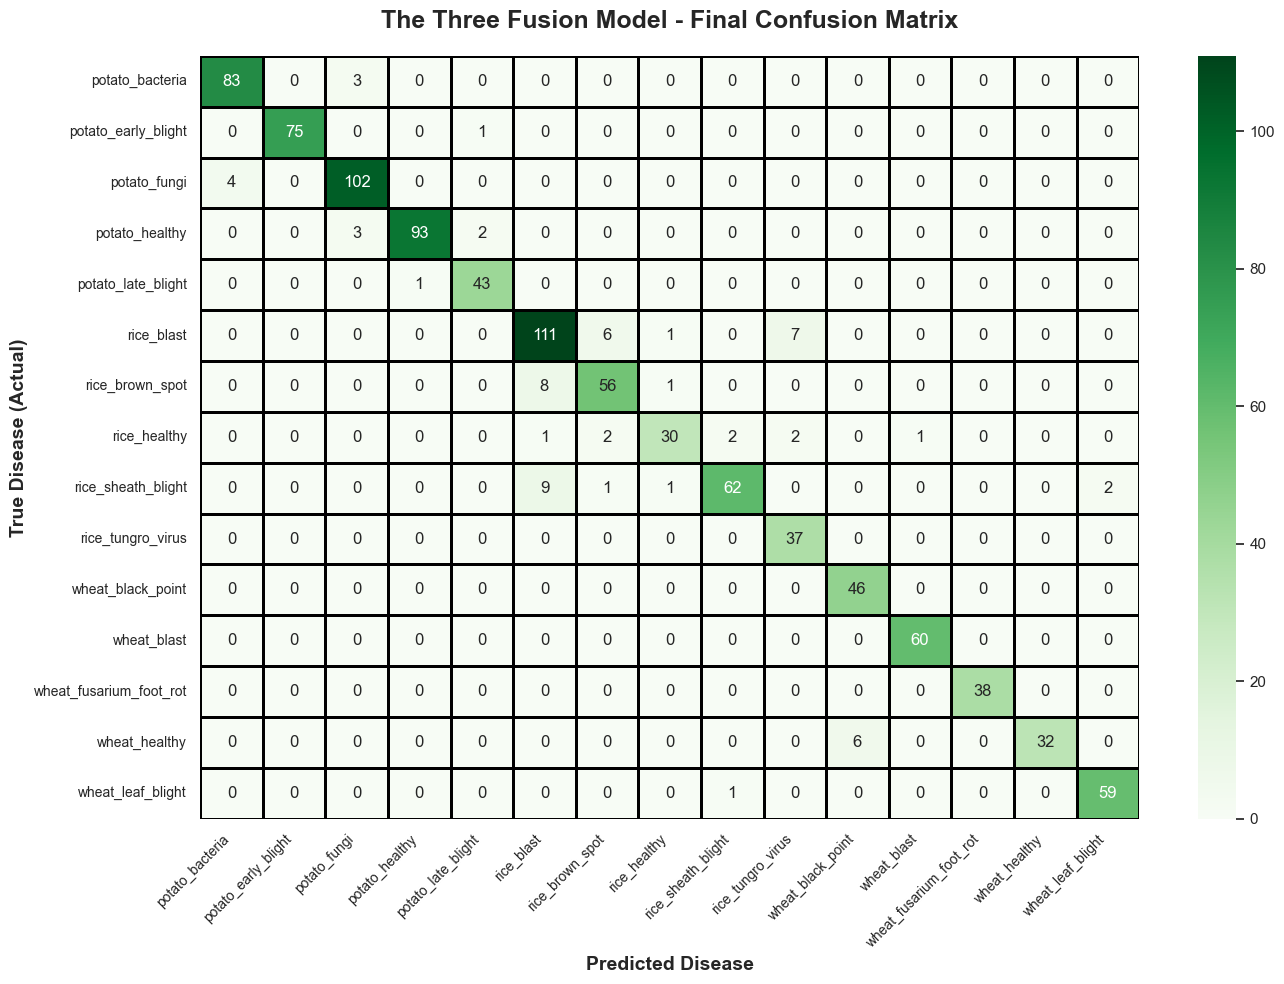

✅ The final benchmark is set!


In [4]:
# ==========================================
# CELL #29 - THE THREE FUSION EVALUATION
# ==========================================
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("📁 Setting up the Unseen Test Data...")

# 🚨 CRITICAL: Unscaled, Unshuffled generator for accurate testing
test_datagen = ImageDataGenerator() 
test_gen = test_datagen.flow_from_directory(
    r"D:\MasterDataset\test", 
    target_size=(224, 224), 
    batch_size=8, 
    class_mode='categorical', 
    shuffle=False 
)

print("\n🧠 Loading the best brain weights into the CEO...")
boss_path = r"D:\Final_Experiment\The_Three_Fusion_Best_Weights.h5"
three_fusion_model.load_weights(boss_path)

# 1. THE ULTIMATE TEST
print("\n📊 Running final evaluation on unseen crops...")
loss, accuracy = three_fusion_model.evaluate(test_gen, verbose=1)
print(f"\n🏆 THE THREE FUSION FINAL TEST ACCURACY: {accuracy * 100:.2f}%")

# 2. GENERATE PREDICTIONS
print("\n🕵️‍♂️ Generating final predictions...")
test_gen.reset() 
predictions = three_fusion_model.predict(test_gen, verbose=1)

predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_gen.classes
class_labels = list(test_gen.class_indices.keys())

# 3. PRINT MASTER CLASSIFICATION REPORT
print("\n📄 --- FINAL FUSION REPORT ---")
report = classification_report(true_classes, predicted_classes, target_names=class_labels)
print(report)

# 4. PLOT THE ULTIMATE CONFUSION MATRIX
print("\n🎨 Plotting The Final Matrix...")
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(14, 10))
sns.set_theme(style="whitegrid") 

# Using a deep, rich 'Purples' or 'Greens' palette for the final model
heatmap = sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
                      xticklabels=class_labels, 
                      yticklabels=class_labels,
                      linewidths=1, linecolor='black')

plt.title('The Three Fusion Model - Final Confusion Matrix', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Predicted Disease', fontsize=14, fontweight='bold')
plt.ylabel('True Disease (Actual)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

print("✅ The final benchmark is set!")

In [5]:
# ==========================================
# CELL #16A - FRESH FEATURE EXTRACTION (NEW FOLDER)
# ==========================================
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("🧹 Scrubbing GPU Memory for a perfectly clean start...")
tf.keras.backend.clear_session()

# The folder where your fine-tuned models live
MODEL_DIR = r"D:\Final_Experiment"

# 🚨 THE NEW FOLDER: Where all the extracted math will safely go
SAVE_DIR = r"D:\Final_Experiment\Offline_Features_V2"
os.makedirs(SAVE_DIR, exist_ok=True)

# ---------------------------------------------------------
# 1. FRESH UNSHUFFLED GENERATORS 
# ---------------------------------------------------------
print(f"📁 Creating fresh data generators...\nSaving outputs to: {SAVE_DIR}")
extract_datagen = ImageDataGenerator() 
train_extract_gen = extract_datagen.flow_from_directory(
    r"D:\MasterDataset\train", target_size=(224, 224), batch_size=16, 
    class_mode='categorical', shuffle=False
)
val_extract_gen = extract_datagen.flow_from_directory(
    r"D:\MasterDataset\val", target_size=(224, 224), batch_size=16, 
    class_mode='categorical', shuffle=False
)

# Save labels to the NEW folder
np.save(os.path.join(SAVE_DIR, "train_labels.npy"), train_extract_gen.classes)
np.save(os.path.join(SAVE_DIR, "val_labels.npy"), val_extract_gen.classes)

# ---------------------------------------------------------
# EXPERT 1: DENSENET121
# ---------------------------------------------------------
print("\n🕵️‍♂️ Loading Detective 1: DenseNet121...")
model_dense = load_model(os.path.join(MODEL_DIR, "DenseNet121_FineTuned.keras"))
feat_dense = Model(inputs=model_dense.input, outputs=model_dense.get_layer("global_pooling").output)

print("⚙️ Extracting Fresh DenseNet Features...")
np.save(os.path.join(SAVE_DIR, "train_feat_dense.npy"), feat_dense.predict(train_extract_gen, verbose=1))
np.save(os.path.join(SAVE_DIR, "val_feat_dense.npy"), feat_dense.predict(val_extract_gen, verbose=1))

del model_dense, feat_dense
tf.keras.backend.clear_session()

# ---------------------------------------------------------
# EXPERT 2: MOBILENETV2
# ---------------------------------------------------------
print("\n🕵️‍♂️ Loading Detective 2: MobileNetV2...")
model_mobile = load_model(os.path.join(MODEL_DIR, "MobileNetV2_FineTuned.keras"))
feat_mobile = Model(inputs=model_mobile.input, outputs=model_mobile.get_layer("global_pooling").output)

print("⚙️ Extracting Fresh MobileNet Features...")
np.save(os.path.join(SAVE_DIR, "train_feat_mobile.npy"), feat_mobile.predict(train_extract_gen, verbose=1))
np.save(os.path.join(SAVE_DIR, "val_feat_mobile.npy"), feat_mobile.predict(val_extract_gen, verbose=1))

del model_mobile, feat_mobile
tf.keras.backend.clear_session()

# ---------------------------------------------------------
# EXPERT 3: EFFICIENTNETB0
# ---------------------------------------------------------
print("\n🕵️‍♂️ Loading Detective 3: EfficientNetB0...")
eff_inputs = Input(shape=(224, 224, 3))
base_eff = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
x = base_eff(eff_inputs, training=False)
x = GlobalAveragePooling2D(name="eff_global_pooling")(x)
x = Dropout(0.3)(x)
eff_outputs = Dense(15, activation='softmax')(x)
model_eff = Model(inputs=eff_inputs, outputs=eff_outputs)
model_eff.load_weights(os.path.join(MODEL_DIR, "EfficientNetB0_TF_Weights"))

feat_eff = Model(inputs=model_eff.input, outputs=model_eff.get_layer("eff_global_pooling").output)

print("⚙️ Extracting Fresh EfficientNet Features...")
np.save(os.path.join(SAVE_DIR, "train_feat_eff.npy"), feat_eff.predict(train_extract_gen, verbose=1))
np.save(os.path.join(SAVE_DIR, "val_feat_eff.npy"), feat_eff.predict(val_extract_gen, verbose=1))

del model_eff, feat_eff
tf.keras.backend.clear_session()

print(f"\n✅ EXTRACTION COMPLETE! The slate is clean, and fresh features are saved in: {SAVE_DIR}")

🧹 Scrubbing GPU Memory for a perfectly clean start...
📁 Creating fresh data generators...
Saving outputs to: D:\Final_Experiment\Offline_Features_V2
Found 4581 images belonging to 15 classes.
Found 978 images belonging to 15 classes.

🕵️‍♂️ Loading Detective 1: DenseNet121...
⚙️ Extracting Fresh DenseNet Features...
62/62 [==============================] - 16s 262ms/step

🕵️‍♂️ Loading Detective 2: MobileNetV2...
⚙️ Extracting Fresh MobileNet Features...
62/62 [==============================] - 10s 153ms/step

🕵️‍♂️ Loading Detective 3: EfficientNetB0...
⚙️ Extracting Fresh EfficientNet Features...
62/62 [==============================] - 9s 150ms/step

✅ EXTRACTION COMPLETE! The slate is clean, and fresh features are saved in: D:\Final_Experiment\Offline_Features_V2


In [6]:
# ==========================================
# CELL #16B - COMPRESSED FEATURE FUSION (NEW FOLDER)
# ==========================================
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Concatenate, Activation
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

print("🧹 Flushing GPU Memory...")
tf.keras.backend.clear_session()

# 🚨 Pointing exactly to your new safe folder!
SAVE_DIR = r"D:\Final_Experiment\Offline_Features_V2"

print("📁 Loading fresh extracted features from the safe folder...")
X_train_dense = np.load(os.path.join(SAVE_DIR, "train_feat_dense.npy"))
X_train_mobile = np.load(os.path.join(SAVE_DIR, "train_feat_mobile.npy"))
X_train_eff = np.load(os.path.join(SAVE_DIR, "train_feat_eff.npy"))

X_val_dense = np.load(os.path.join(SAVE_DIR, "val_feat_dense.npy"))
X_val_mobile = np.load(os.path.join(SAVE_DIR, "val_feat_mobile.npy"))
X_val_eff = np.load(os.path.join(SAVE_DIR, "val_feat_eff.npy"))

y_train = to_categorical(np.load(os.path.join(SAVE_DIR, "train_labels.npy")), num_classes=15)
y_val = to_categorical(np.load(os.path.join(SAVE_DIR, "val_labels.npy")), num_classes=15)

print("🏗️ Assembling the Compressed Feature Boss...")
# Gate 1: DenseNet
input_dense = Input(shape=(1024,), name="Input_DenseNet")
comp_dense = Dense(256, name="Compress_Dense")(input_dense)
comp_dense = BatchNormalization()(comp_dense)
comp_dense = Activation('relu')(comp_dense)
comp_dense = Dropout(0.3)(comp_dense)

# Gate 2: MobileNet
input_mobile = Input(shape=(1280,), name="Input_MobileNet")
comp_mobile = Dense(256, name="Compress_Mobile")(input_mobile)
comp_mobile = BatchNormalization()(comp_mobile)
comp_mobile = Activation('relu')(comp_mobile)
comp_mobile = Dropout(0.3)(comp_mobile)

# Gate 3: EfficientNet
input_eff = Input(shape=(1280,), name="Input_EfficientNet")
comp_eff = Dense(256, name="Compress_Efficient")(input_eff)
comp_eff = BatchNormalization()(comp_eff)
comp_eff = Activation('relu')(comp_eff)
comp_eff = Dropout(0.3)(comp_eff)

# Merge the clean, summarized features (768 total)
merged_clean = Concatenate(name="Clean_Feature_Merger")([comp_dense, comp_mobile, comp_eff])

# The Final Master Analyst
x = Dense(128, activation='relu', name="Final_Analyst")(merged_clean)
x = Dropout(0.2)(x)
final_output = Dense(15, activation='softmax', name="Ultimate_Prediction")(x)

feature_boss_model = Model(
    inputs=[input_dense, input_mobile, input_eff], 
    outputs=final_output, 
    name="Compressed_Feature_Boss"
)

feature_boss_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Save the trained boss back into the safe folder
feat_fusion_path = os.path.join(SAVE_DIR, "Offline_Boss_V2.keras")
callbacks = [
    ModelCheckpoint(feat_fusion_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

print("\n🚀 Starting Training (Batch Size = 32 for maximum accuracy!)...")
history = feature_boss_model.fit(
    [X_train_dense, X_train_mobile, X_train_eff], y_train,
    validation_data=([X_val_dense, X_val_mobile, X_val_eff], y_val),
    epochs=25, 
    batch_size=32, # 🚨 We can safely use 32 here because no images are in RAM!
    callbacks=callbacks
)

print(f"\n👑 OFFLINE BOSS TRAINING COMPLETE! Model safely saved to: {feat_fusion_path}")

🧹 Flushing GPU Memory...
📁 Loading fresh extracted features from the safe folder...
🏗️ Assembling the Compressed Feature Boss...

🚀 Starting Training (Batch Size = 32 for maximum accuracy!)...
Epoch 1/25
140/144 [============================>.] - ETA: 0s - loss: 0.4590 - accuracy: 0.8500
Epoch 1: val_accuracy improved from -inf to 0.94990, saving model to D:\Final_Experiment\Offline_Features_V2\Offline_Boss_V2.keras
144/144 [==============================] - 3s 12ms/step - loss: 0.4522 - accuracy: 0.8524 - val_loss: 0.1699 - val_accuracy: 0.9499 - lr: 0.0010
Epoch 2/25
140/144 [============================>.] - ETA: 0s - loss: 0.1352 - accuracy: 0.9565
Epoch 2: val_accuracy improved from 0.94990 to 0.95399, saving model to D:\Final_Experiment\Offline_Features_V2\Offline_Boss_V2.keras
144/144 [==============================] - 1s 9ms/step - loss: 0.1365 - accuracy: 0.9559 - val_loss: 0.1620 - val_accuracy: 0.9540 - lr: 0.0010
Epoch 3/25
142/144 [============================>.] - ETA: 0s

🧹 Scrubbing GPU Memory for the Final Deployment Test...
📁 Loading Unseen Test Data...
Found 992 images belonging to 15 classes.

🕵️‍♂️ Loading Detectives for Production Stitching...
🧠 Loading the Offline Boss (V2)...
🔗 Stitching the End-to-End Evaluation Pipeline...

📊 Testing Stitched App on Unseen Crops...
124/124 [==============================] - 24s 146ms/step - loss: 0.1272 - accuracy: 0.9627

🏆 OFFLINE METHOD (STITCHED) TEST ACCURACY: 96.27%

🕵️‍♂️ Generating predictions for the Matrix...
124/124 [==============================] - 16s 97ms/step

📄 --- FINAL OFFLINE V2 REPORT ---
                         precision    recall  f1-score   support

        potato_bacteria       0.98      0.98      0.98        86
    potato_early_blight       1.00      0.99      0.99        76
           potato_fungi       0.95      0.98      0.96       106
         potato_healthy       1.00      0.96      0.98        98
     potato_late_blight       0.98      1.00      0.99        44
             ric

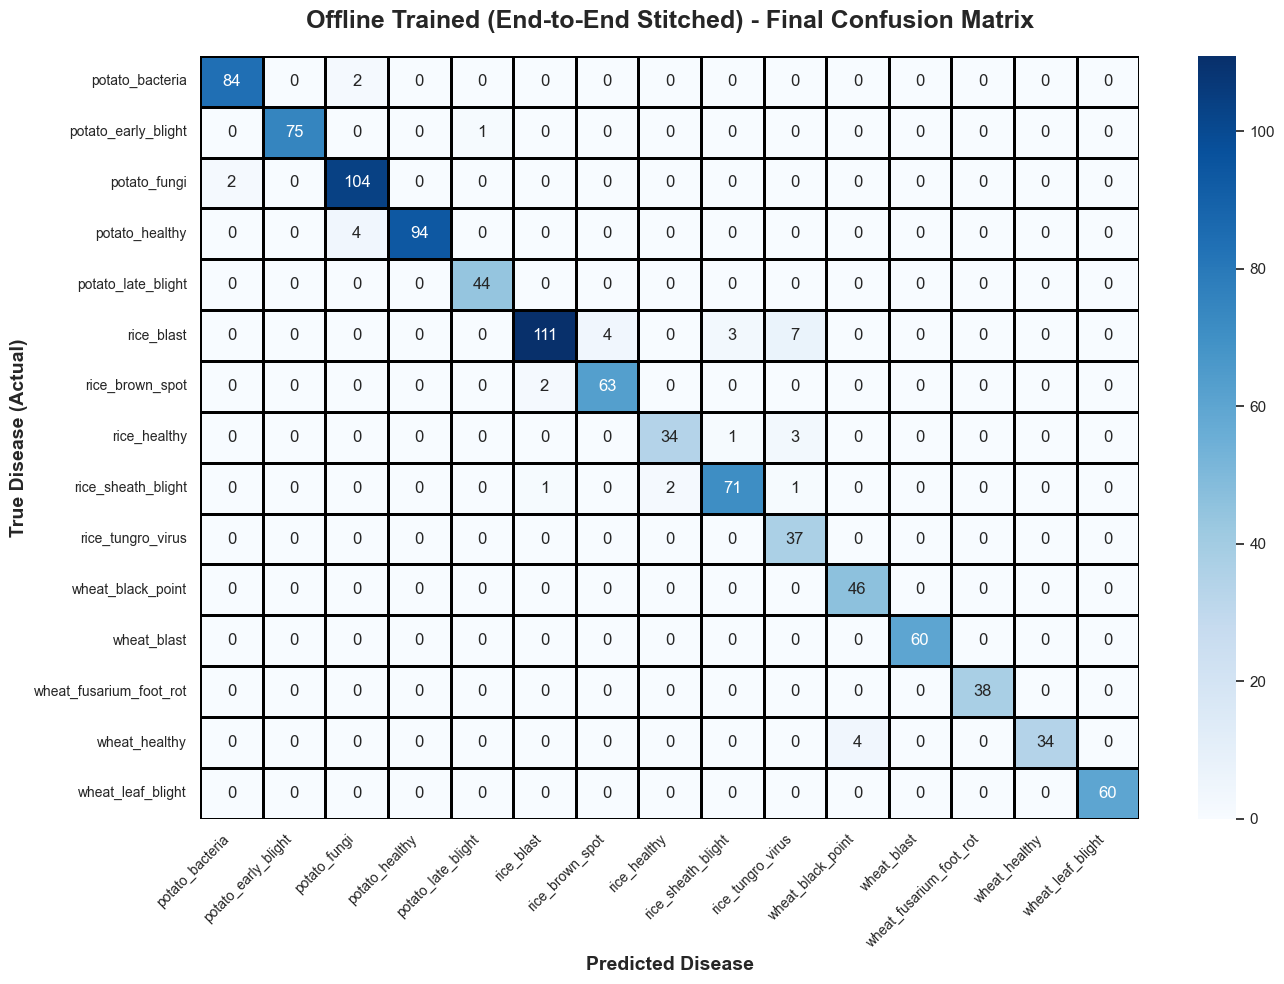

✅ The ultimate benchmark is permanently set!


In [7]:
# ==========================================
# CELL #17 - STITCH & TEST (OFFLINE BOSS V2)
# ==========================================
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

print("🧹 Scrubbing GPU Memory for the Final Deployment Test...")
tf.keras.backend.clear_session()

# The two folders we are pulling from
MODEL_DIR = r"D:\Final_Experiment"
SAVE_DIR = r"D:\Final_Experiment\Offline_Features_V2"

# ---------------------------------------------------------
# 1. LOAD TEST DATA (Raw Pixels, Unshuffled)
# ---------------------------------------------------------
print("📁 Loading Unseen Test Data...")
test_datagen = ImageDataGenerator() 
test_gen = test_datagen.flow_from_directory(
    r"D:\MasterDataset\test", 
    target_size=(224, 224), 
    batch_size=8, # Hardware safe inference
    class_mode='categorical', 
    shuffle=False # CRITICAL for matching predictions to true labels
)

# ---------------------------------------------------------
# 2. LOAD & FREEZE THE THREE DETECTIVES
# ---------------------------------------------------------
print("\n🕵️‍♂️ Loading Detectives for Production Stitching...")
# Detective 1: DenseNet
base_dense = load_model(os.path.join(MODEL_DIR, "DenseNet121_FineTuned.keras"))
ext_dense = Model(inputs=base_dense.input, outputs=base_dense.get_layer("global_pooling").output, name="Dense_Ext")
ext_dense.trainable = False

# Detective 2: MobileNet
base_mobile = load_model(os.path.join(MODEL_DIR, "MobileNetV2_FineTuned.keras"))
ext_mobile = Model(inputs=base_mobile.input, outputs=base_mobile.get_layer("global_pooling").output, name="Mobile_Ext")
ext_mobile.trainable = False

# Detective 3: EfficientNet (Rebuilt to bypass JSON bug)
eff_inputs = Input(shape=(224, 224, 3))
b_eff = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
x_eff = b_eff(eff_inputs, training=False)
feat_eff = GlobalAveragePooling2D(name="eff_global_pooling")(x_eff)
ext_eff = Model(inputs=eff_inputs, outputs=feat_eff, name="Eff_Ext")
ext_eff.load_weights(os.path.join(MODEL_DIR, "EfficientNetB0_TF_Weights")).expect_partial()
ext_eff.trainable = False

# ---------------------------------------------------------
# 3. LOAD THE OFFLINE TRAINED BOSS
# ---------------------------------------------------------
print("🧠 Loading the Offline Boss (V2)...")
boss_model = load_model(os.path.join(SAVE_DIR, "Offline_Boss_V2.keras"))

# ---------------------------------------------------------
# 4. STITCH THE FULL APP TOGETHER
# ---------------------------------------------------------
print("🔗 Stitching the End-to-End Evaluation Pipeline...")
farmer_input = Input(shape=(224, 224, 3), name="Raw_Camera_Image")

f1 = ext_dense(farmer_input)
f2 = ext_mobile(farmer_input)
f3 = ext_eff(farmer_input)

final_pred = boss_model([f1, f2, f3])

production_model = Model(inputs=farmer_input, outputs=final_pred, name="Final_Offline_Stitched_App")

# Must compile before evaluating!
production_model.compile(
    optimizer='adam', 
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

# ---------------------------------------------------------
# 5. EVALUATE & PLOT
# ---------------------------------------------------------
print("\n📊 Testing Stitched App on Unseen Crops...")
loss, accuracy = production_model.evaluate(test_gen, verbose=1)
print(f"\n🏆 OFFLINE METHOD (STITCHED) TEST ACCURACY: {accuracy * 100:.2f}%")

print("\n🕵️‍♂️ Generating predictions for the Matrix...")
test_gen.reset()
predictions = production_model.predict(test_gen, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_gen.classes
class_labels = list(test_gen.class_indices.keys())

print("\n📄 --- FINAL OFFLINE V2 REPORT ---")
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

print("\n🎨 Plotting The Final Matrix...")
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(14, 10))
sns.set_theme(style="whitegrid") 

# Using a distinct 'Blues' palette for this final offline architecture run
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, yticklabels=class_labels, 
            linewidths=1, linecolor='black')

plt.title('Offline Trained (End-to-End Stitched) - Final Confusion Matrix', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Predicted Disease', fontsize=14, fontweight='bold')
plt.ylabel('True Disease (Actual)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

print("✅ The ultimate benchmark is permanently set!")

📝 Initiating Final Exam for The Three Fusion Boss...

📁 Setting up the Unseen Test Data...
Found 992 images belonging to 15 classes.

🧠 Loading and Stitching Models from the Hard Drive...

📊 Evaluating The Three Fusion App on unseen Test Set...
124/124 [==============================] - 59s 264ms/step - loss: 0.1272 - accuracy: 0.9627

🏆 Official Three Fusion Test Accuracy: 96.27%
🔍 Generating detailed predictions...

--- Thesis Documentation: Three Fusion Boss Classification Report ---
                         precision    recall  f1-score   support

        potato_bacteria       0.98      0.98      0.98        86
    potato_early_blight       1.00      0.99      0.99        76
           potato_fungi       0.95      0.98      0.96       106
         potato_healthy       1.00      0.96      0.98        98
     potato_late_blight       0.98      1.00      0.99        44
             rice_blast       0.97      0.89      0.93       125
        rice_brown_spot       0.94      0.97      0.

NameError: name 'FINAL_DIR' is not defined

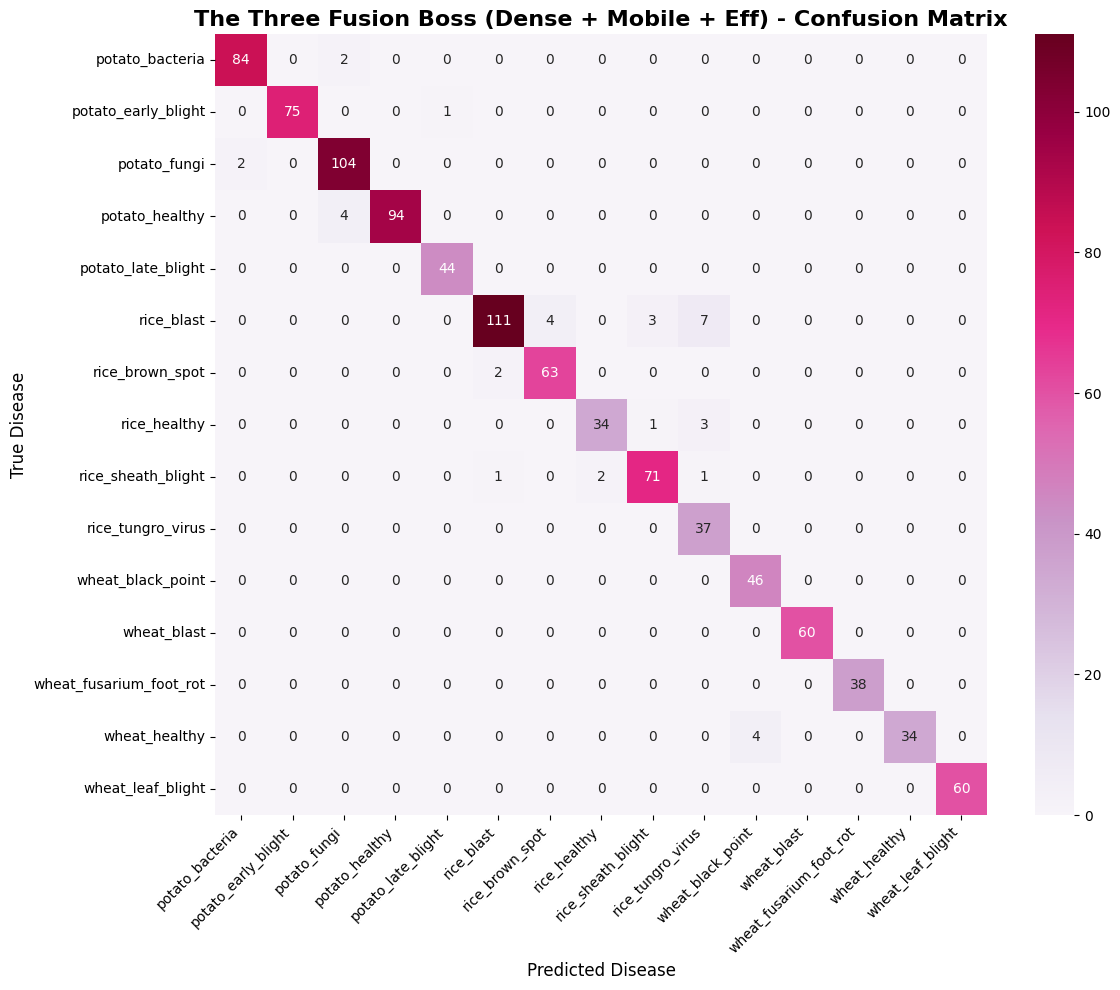

In [2]:
# ==========================================
# CELL #30 - THESIS DOCUMENTATION: FINAL EVALUATION
# ==========================================
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import Input, GlobalAveragePooling2D
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

print("📝 Initiating Final Exam for The Three Fusion Boss...")

MODEL_DIR = r"D:\Final_Experiment"
SAVE_DIR = r"D:\Final_Experiment\Offline_Features_V2"

# ---------------------------------------------------------
# 1. LOAD TEST DATA
# ---------------------------------------------------------
print("\n📁 Setting up the Unseen Test Data...")
test_datagen = ImageDataGenerator() 
test_gen = test_datagen.flow_from_directory(
    r"D:\MasterDataset\test", 
    target_size=(224, 224), 
    batch_size=8, 
    class_mode='categorical', 
    shuffle=False 
)

# ---------------------------------------------------------
# 2. LOAD MODELS AND STITCH THEM LIVE
# ---------------------------------------------------------
print("\n🧠 Loading and Stitching Models from the Hard Drive...")
base_dense = load_model(os.path.join(MODEL_DIR, "DenseNet121_FineTuned.keras"))
ext_dense = Model(inputs=base_dense.input, outputs=base_dense.get_layer("global_pooling").output)

base_mobile = load_model(os.path.join(MODEL_DIR, "MobileNetV2_FineTuned.keras"))
ext_mobile = Model(inputs=base_mobile.input, outputs=base_mobile.get_layer("global_pooling").output)

eff_inputs = Input(shape=(224, 224, 3))
b_eff = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
x_eff = b_eff(eff_inputs, training=False)
feat_eff = GlobalAveragePooling2D(name="eff_global_pooling")(x_eff)
ext_eff = Model(inputs=eff_inputs, outputs=feat_eff)
ext_eff.load_weights(os.path.join(MODEL_DIR, "EfficientNetB0_TF_Weights")).expect_partial()

boss_model = load_model(os.path.join(SAVE_DIR, "Offline_Boss_V2.keras"))

# Stitching the Master App
farmer_input = Input(shape=(224, 224, 3), name="Raw_Camera_Image")
f1 = ext_dense(farmer_input)
f2 = ext_mobile(farmer_input)
f3 = ext_eff(farmer_input)
final_pred = boss_model([f1, f2, f3])
production_model = Model(inputs=farmer_input, outputs=final_pred)

# Compile before evaluating
production_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# ---------------------------------------------------------
# 3. EVALUATE & PLOT
# ---------------------------------------------------------
print("\n📊 Evaluating The Three Fusion App on unseen Test Set...")
test_loss, test_acc = production_model.evaluate(test_gen, verbose=1)
print(f"\n🏆 Official Three Fusion Test Accuracy: {test_acc * 100:.2f}%")

print("🔍 Generating detailed predictions...")
test_gen.reset()
predictions = production_model.predict(test_gen, verbose=0)
y_pred = np.argmax(predictions, axis=1)
y_test_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

print("\n--- Thesis Documentation: Three Fusion Boss Classification Report ---")
print(classification_report(y_test_true, y_pred, target_names=class_names))

plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_test_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='PuRd', xticklabels=class_names, yticklabels=class_names)
plt.title('The Three Fusion Boss (Dense + Mobile + Eff) - Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('True Disease', fontsize=12)
plt.xlabel('Predicted Disease', fontsize=12)
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()

cm_path = os.path.join(FINAL_DIR, "Three_Fusion_Boss_Confusion_Matrix.png")
plt.savefig(cm_path)
print(f"✅ Confusion Matrix safely saved to {cm_path}")
plt.show()

In [1]:
# ==========================================
# CELL #31 - BAKING THE SINGLE-FILE APP
# ==========================================
import os
import tensorflow as tf
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import Input, GlobalAveragePooling2D
from tensorflow.keras.applications import EfficientNetB0

print("🔥 Firing up the oven to bake the Final App...")

FINAL_DIR = r"D:\Final_Experiment"
MODEL_DIR = r"D:\Final_Experiment"
SAVE_DIR = r"D:\Final_Experiment\Offline_Features_V2"

# 1. LOAD THE PIECES ONE LAST TIME
print("Grabbing the pieces...")
base_dense = load_model(os.path.join(MODEL_DIR, "DenseNet121_FineTuned.keras"))
ext_dense = Model(inputs=base_dense.input, outputs=base_dense.get_layer("global_pooling").output)

base_mobile = load_model(os.path.join(MODEL_DIR, "MobileNetV2_FineTuned.keras"))
ext_mobile = Model(inputs=base_mobile.input, outputs=base_mobile.get_layer("global_pooling").output)

eff_inputs = Input(shape=(224, 224, 3))
b_eff = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
x_eff = b_eff(eff_inputs, training=False)
feat_eff = GlobalAveragePooling2D(name="eff_global_pooling")(x_eff)
ext_eff = Model(inputs=eff_inputs, outputs=feat_eff)
ext_eff.load_weights(os.path.join(MODEL_DIR, "EfficientNetB0_TF_Weights")).expect_partial()

boss_model = load_model(os.path.join(SAVE_DIR, "Offline_Boss_V2.keras"))

# 2. STITCH THEM TOGETHER
print("🔗 Gluing them together...")
farmer_input = Input(shape=(224, 224, 3), name="Raw_Camera_Image")
f1 = ext_dense(farmer_input)
f2 = ext_mobile(farmer_input)
f3 = ext_eff(farmer_input)
final_pred = boss_model([f1, f2, f3])

# THIS is the master container
production_model = Model(inputs=farmer_input, outputs=final_pred)

# 3. SAVE AS ONE SINGLE PACKAGE (RAW TF BYPASS)
print("📦 Freezing the pure computational graph (Bypassing Keras JSON)...")

final_app_path = os.path.join(FINAL_DIR, "The_Ultimate_Crop_App")

# 🚨 THE FIX: Use tf.saved_model instead of production_model.save()
tf.saved_model.save(production_model, final_app_path)

print(f"\n✅ ABSOLUTE SUCCESS! You now have a single, unified app saved at: {final_app_path}")

🔥 Firing up the oven to bake the Final App...
Grabbing the pieces...
🔗 Gluing them together...
📦 Freezing the pure computational graph (Bypassing Keras JSON)...


INFO:tensorflow:Assets written to: D:\Final_Experiment\The_Ultimate_Crop_App\assets


INFO:tensorflow:Assets written to: D:\Final_Experiment\The_Ultimate_Crop_App\assets



✅ ABSOLUTE SUCCESS! You now have a single, unified app saved at: D:\Final_Experiment\The_Ultimate_Crop_App


📝 Initiating Independent Evaluation for the Unified Production App...

📁 Setting up the Unseen Test Data...
Found 992 images belonging to 15 classes.

🧠 Loading the complete baked model from: D:\Final_Experiment\The_Ultimate_Crop_App
✅ Master App Graph successfully memory-mapped!

🕵️‍♂️ Running final predictions across all test patches...
   -> Processed batch 20/124
   -> Processed batch 40/124
   -> Processed batch 60/124
   -> Processed batch 80/124
   -> Processed batch 100/124
   -> Processed batch 120/124
   -> Processed batch 124/124

🏆 STANDALONE PACKAGED APP TEST ACCURACY: 96.27%

📄 --- THESIS DOCUMENTATION: STANDALONE APP PERFORMANCE ---
                         precision    recall  f1-score   support

        potato_bacteria       0.98      0.98      0.98        86
    potato_early_blight       1.00      0.99      0.99        76
           potato_fungi       0.95      0.98      0.96       106
         potato_healthy       1.00      0.96      0.98        98
     potato_late_b

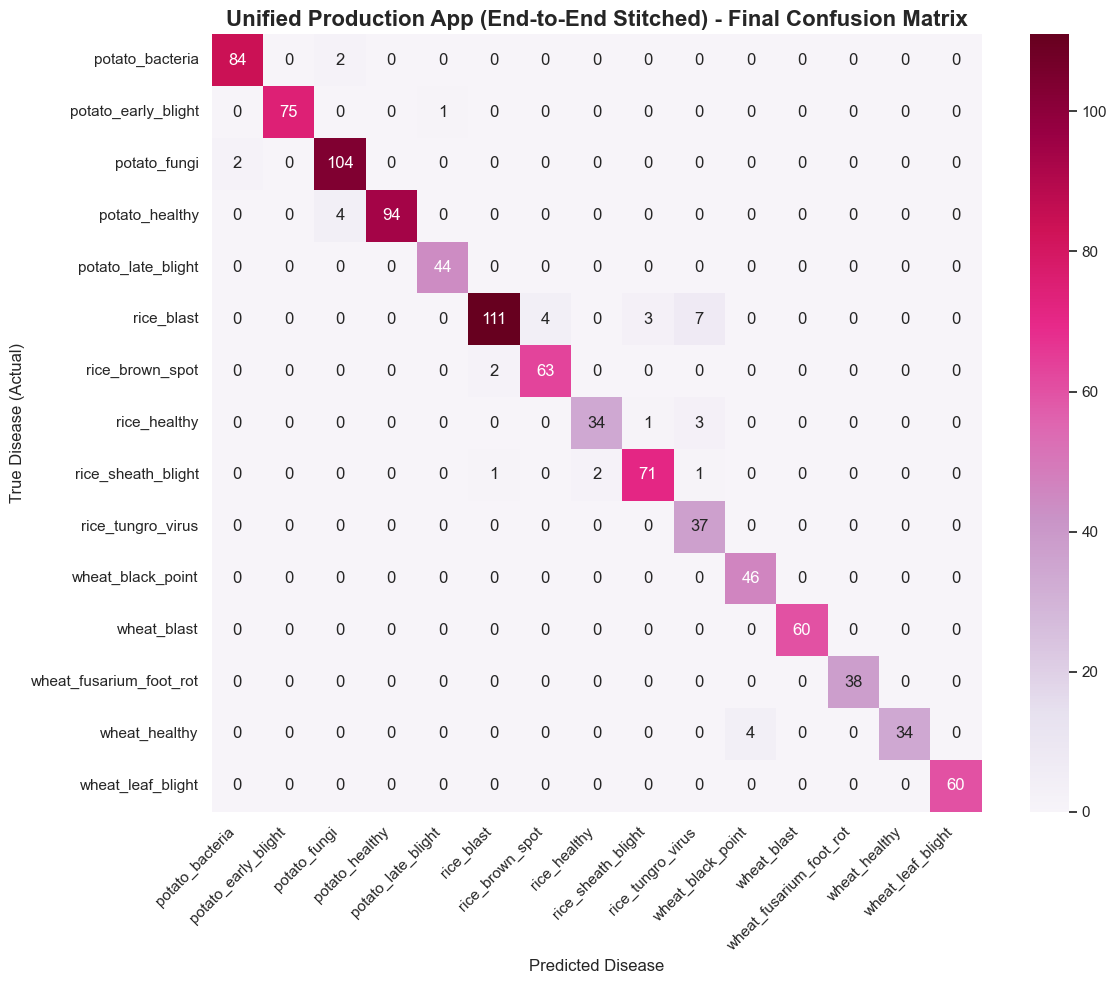


👑 All steps complete. Your deployable product is verified!


In [3]:
# ==========================================
# CELL #32 - STANDALONE PRODUCT EVALUATION
# ==========================================
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

print("📝 Initiating Independent Evaluation for the Unified Production App...")

FINAL_DIR = r"D:\Final_Experiment"
APP_PATH = os.path.join(FINAL_DIR, "The_Ultimate_Crop_App")

# ---------------------------------------------------------
# 1. LOAD TEST DATA (Raw Pixels, Unshuffled)
# ---------------------------------------------------------
print("\n📁 Setting up the Unseen Test Data...")
test_datagen = ImageDataGenerator() 
test_gen = test_datagen.flow_from_directory(
    r"D:\MasterDataset\test", 
    target_size=(224, 224), 
    batch_size=8, 
    class_mode='categorical', 
    shuffle=False 
)

# ---------------------------------------------------------
# 2. LOAD THE ONE SINGLE UNIFIED MODEL
# ---------------------------------------------------------
print(f"\n🧠 Loading the complete baked model from: {APP_PATH}")
final_production_app = tf.saved_model.load(APP_PATH)
infer = final_production_app.signatures["serving_default"]
print("✅ Master App Graph successfully memory-mapped!")

# ---------------------------------------------------------
# 3. RUN INFERENCE OVER THE TEST GENERATOR
# ---------------------------------------------------------
print("\n🕵️‍♂️ Running final predictions across all test patches...")
all_predictions = []
true_classes = []

num_batches = int(np.ceil(test_gen.samples / test_gen.batch_size))
for i in range(num_batches):
    imgs, labels = next(test_gen)
    
    input_tensor = tf.convert_to_tensor(imgs, dtype=tf.float32)
    
    # 🚨 THE FIX: Using the exact original casing TensorFlow demanded
    predictions_dict = infer(Raw_Camera_Image=input_tensor)
    
    output_key = list(predictions_dict.keys())[0]
    preds = predictions_dict[output_key].numpy()
    
    all_predictions.extend(preds)
    true_classes.extend(np.argmax(labels, axis=1))
    
    if (i + 1) % 20 == 0 or (i + 1) == num_batches:
        print(f"   -> Processed batch {i + 1}/{num_batches}")

all_predictions = np.array(all_predictions)
predicted_classes = np.argmax(all_predictions, axis=1)
true_classes = np.array(true_classes)
class_labels = list(test_gen.class_indices.keys())

# ---------------------------------------------------------
# 4. CALCULATE ACCURACY & GENERATE REPORTS
# ---------------------------------------------------------
final_accuracy = np.mean(predicted_classes == true_classes)
print(f"\n🏆 STANDALONE PACKAGED APP TEST ACCURACY: {final_accuracy * 100:.2f}%")

print("\n📄 --- THESIS DOCUMENTATION: STANDALONE APP PERFORMANCE ---")
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

# ---------------------------------------------------------
# 5. PLOT AND SAVE PURPLE-RED CONFUSION MATRIX
# ---------------------------------------------------------
print("\n🎨 Rendering Final Confusion Matrix...")
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(12, 10))
sns.set_theme(style="whitegrid")

sns.heatmap(cm, annot=True, fmt='d', cmap='PuRd', 
            xticklabels=class_labels, yticklabels=class_labels)

plt.title('Unified Production App (End-to-End Stitched) - Final Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('True Disease (Actual)', fontsize=12)
plt.xlabel('Predicted Disease', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

cm_save_path = os.path.join(FINAL_DIR, "Production_App_Final_Confusion_Matrix.png")
plt.savefig(cm_save_path)
print(f"✅ Production Confusion Matrix safely saved to {cm_save_path}")
plt.show()

print("\n👑 All steps complete. Your deployable product is verified!")